# SerialGuard
## 1. Machine Learning–Based VIN Anomaly and Authenticity Detection

**Project:** SerialGuard · **Domain:** ML / anomaly detection / automotive data  
**Primary task:** Binary anomaly detection · **Secondary task:** Novel anomaly detection  
**Learning paradigms:** Supervised, unsupervised and one-class learning  
**Deployment:** Gradio · **Environment:** Google Colab

Upload this notebook to Colab and choose **Runtime → Run all**. No dataset upload, key,
account connection or Drive mount is needed. The default experiment uses 2,400 source
groups and 9,600 rows. CPU execution is supported; runtime depends on the Colab allocation
and package downloads. Set `QUICK_MODE = True` for a smaller engineering smoke test.

**What “authenticity” means here:** this project measures conformance to selected VIN
rules and similarity to a controlled synthetic distribution. It cannot establish vehicle
authenticity. **SerialGuard does not determine whether a vehicle is stolen, cloned,
counterfeit, legally registered, or fraudulent.**

All training identifiers are **structurally generated examples**, never observed vehicles.
Manufacturer references come from NHTSA. Descriptor and plant distributions are explicitly
simulated. Hard-case labels mean “transformed by our benchmark,” not “known invalid VIN.”
This distinction makes an honest negative result as valuable as a high score.


## 2. Problem definition and experimental contract

The central question is whether learned patterns identify subtle transformations that a
local rule engine misses. Three mechanisms are evaluated: rules, supervised classification,
and normal-only representation learning. A fixed hybrid combines all three.

The benchmark has easy rule-breaking cases and a separate **hard, rule-passing** subset.
Two hard controls change a serial digit or swap serial digits and repair the checksum.
Because the serial distribution is uniform, these controls can be statistically
indistinguishable from normals. Failure to recognize them is expected and is not concealed.
Other hard cases stress the *simulated* descriptor/plant distribution; success on these
does not demonstrate learning actual manufacturer semantics.

The split, generators, feature groups, model grids, novel mechanisms, and hybrid policy
are specified before test evaluation. Training-only EDA cannot justify later test tuning.
The validation groups are further divided into calibration and model-selection subsets.
Every source and all its descendants share a single partition. Metrics use anomaly = 1.


## 3. VIN background and rule scope

A modern VIN contains 17 positions. WMI occupies 1–3; the descriptor occupies 4–8
(often grouped with position 9 as VDS); position 9 is the U.S. check digit; VIS is 10–17.
Position 10 encodes a repeating model-year cycle and 11 is the plant code. Manufacturer
submissions define descriptor meanings. A three-character WMI is insufficient for
low-volume identifiers whose third character is 9.

The local scope is U.S.-market, high-volume passenger-car syntax: ASCII VIN characters
exclude I/O/Q; the last five positions are numeric. The benchmark uses the 2010–2039
year cycle, indicated by alphabetic position 7. The analyzer permits both year cycles
and does not infer a unique year without the applicable vehicle context.

The checksum transliterates letters to numeric values, multiplies by positional weights,
and takes the sum modulo 11; remainder 10 maps to X. A matching checksum detects some
transcription errors, not identity. Reference absence is a coverage warning, not proof
that a WMI is unassigned. Foreign-market and low-volume inputs need separate validation.

Rule basis: [49 CFR Part 565, official 2023 annual edition, §§565.13–565.15](https://www.govinfo.gov/content/pkg/CFR-2023-title49-vol6/pdf/CFR-2023-title49-vol6-part565-subpartB.pdf).
This is a versioned engineering rule subset, not an exhaustive compliance certification.


## 4. Architecture and methodology

```text
Public NHTSA WMI reference → validate/cache/clean → synthetic source VINs
 → normalize/deduplicate → split source groups → create descendants within groups
 → training-only features → supervised models / normal-only detectors / rules
 → validation calibration, tuning and threshold lock → one final test evaluation
 → easy/hard, novel, severity and error analysis → hybrid engine → Gradio
```

The order deliberately places the group split **before** corruption. Random row splitting
would expose close relatives of test records during training and overstate performance.
The reference is external knowledge, not fitted from test labels. A train-only WMI frequency
feature separately measures rarity in the generated training population.


## 5. Environment setup

Install the small set of notebook dependencies before importing them. Colab supplies
PyTorch; it is installed only if missing. CPU and CUDA builds may differ, so the manifest
records the actual runtime. The fixed package versions below were selected for a consistent
scikit-learn/XGBoost/Gradio API. Installation output is suppressed unless a command fails.


In [1]:
import subprocess, sys, importlib.util
packages = ["numpy==2.1.3", "pandas==2.2.3", "scipy==1.15.2",
            "scikit-learn==1.6.1", "xgboost==2.1.4", "matplotlib==3.10.1",
            "seaborn==0.13.2", "requests==2.32.3", "joblib==1.4.2", "gradio==5.49.1",
            "huggingface-hub==0.35.3", "pydantic==2.11.10", "fastapi==0.116.1"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch==2.6.0"])


## 6. Configuration and reproducibility

All adjustable controls live here. The notebook writes artifacts under
`/content/serialguard/outputs` in Colab and a local `serialguard` folder elsewhere.
One seed drives Python, NumPy, scikit-learn and PyTorch. Deterministic PyTorch operations
are requested, but identical floating-point results across hardware are not guaranteed.


In [2]:
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
from itertools import groupby
from copy import deepcopy
import os, re, json, time, random, hashlib, logging, platform, warnings
import numpy as np
import pandas as pd
import scipy, scipy.sparse as sp
import requests, joblib, sklearn, torch, xgboost, gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, roc_curve,
    precision_recall_curve, brier_score_loss, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

QUICK_MODE = False
RANDOM_STATE = 42
N_SOURCE = 480 if QUICK_MODE else 2400
ANOMALIES_PER_SOURCE = 3
AE_EPOCHS = 15 if QUICK_MODE else 55
AE_PATIENCE = 6
N_JOBS = 1
LAUNCH_DEMO = True
ROOT = Path("/content/serialguard") if Path("/content").exists() else Path.cwd() / "serialguard"
CACHE, OUT = ROOT / "cache", ROOT / "outputs"
for folder in (CACHE, OUT, OUT / "figures", OUT / "models"):
    folder.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_num_threads(N_JOBS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi":110, "savefig.dpi":160, "axes.titleweight":"bold"})
CONFIG = dict(benchmark_version="SerialGuard-1.0", random_state=RANDOM_STATE,
              quick_mode=QUICK_MODE, n_source=N_SOURCE, anomalies_per_source=ANOMALIES_PER_SOURCE,
              ae_epochs=AE_EPOCHS, split=[.70,.15,.15], scope="US high-volume passenger-car syntax")
VERSIONS = {m.__name__:m.__version__ for m in
            [np,pd,scipy,sklearn,torch,xgboost,gr]}
VERSIONS.update(python=sys.version, platform=platform.platform(), device=str(DEVICE))
print(json.dumps(VERSIONS, indent=2))
print(json.dumps(CONFIG, indent=2))
def save_json(obj, name):
    (OUT / name).write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
def finish_plot(name):
    plt.tight_layout()
    plt.savefig(OUT / "figures" / (name + ".png"), bbox_inches="tight")
    plt.show()
    plt.close()
save_json(CONFIG, "configuration.json")
save_json(VERSIONS, "environment.json")


{
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scipy": "1.15.2",
  "sklearn": "1.6.1",
  "torch": "2.11.0+cpu",
  "xgboost": "2.1.4",
  "gradio": "5.49.1",
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "device": "cpu"
}
{
  "benchmark_version": "SerialGuard-1.0",
  "random_state": 42,
  "quick_mode": false,
  "n_source": 2400,
  "anomalies_per_source": 3,
  "ae_epochs": 55,
  "split": [
    0.7,
    0.15,
    0.15
  ],
  "scope": "US high-volume passenger-car syntax"
}


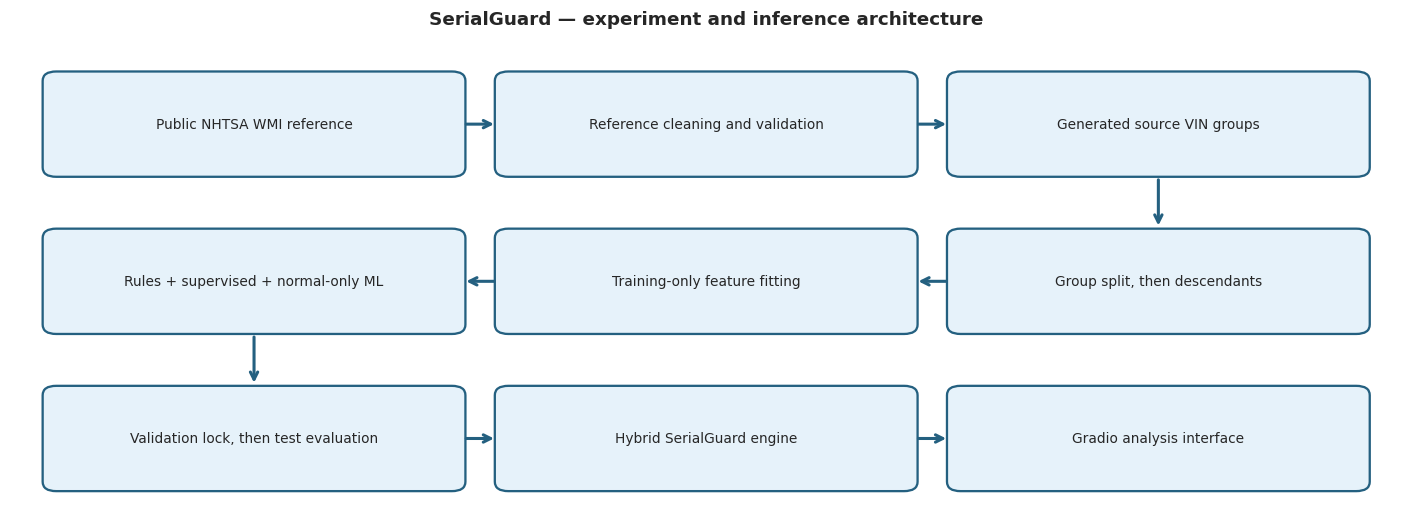

In [3]:
from matplotlib.patches import FancyBboxPatch
architecture=["Public NHTSA WMI reference","Reference cleaning and validation",
    "Generated source VIN groups","Group split, then descendants","Training-only feature fitting",
    "Rules + supervised + normal-only ML","Validation lock, then test evaluation",
    "Hybrid SerialGuard engine","Gradio analysis interface"]
positions=[(0,2),(1,2),(2,2),(2,1),(1,1),(0,1),(0,0),(1,0),(2,0)]
fig,ax=plt.subplots(figsize=(13,5))
for i,(label,(x,y)) in enumerate(zip(architecture,positions)):
    ax.add_patch(FancyBboxPatch((x*4,y*2),3.5,1.1,boxstyle="round,pad=0.12",
        facecolor="#e6f2fa",edgecolor="#246080",linewidth=1.5))
    ax.text(x*4+1.75,y*2+.55,label,ha="center",va="center",fontsize=9)
    if i:
        px,py=positions[i-1]
        if py==y:
            sign=1 if x>px else -1
            start=(px*4+1.75+sign*1.85,py*2+.55)
            end=(x*4+1.75-sign*1.85,y*2+.55)
        else:
            start=(px*4+1.75,py*2-.12); end=(x*4+1.75,y*2+1.22)
        ax.annotate("",xy=end,xytext=start,arrowprops=dict(arrowstyle="->",color="#246080",lw=2))
ax.set(xlim=(-.4,11.9),ylim=(-.5,5.7),title="SerialGuard — experiment and inference architecture")
ax.axis("off")
finish_plot("architecture")


## 7. Automated authoritative reference ingestion

**Source:** NHTSA Product Information Catalog and Vehicle Listing (vPIC), U.S. Department
of Transportation. [API documentation](https://vpic.nhtsa.dot.gov/api/) and
[standalone database downloads](https://vpic.nhtsa.dot.gov/Downloads).
The API returns manufacturer-submitted WMI reference records; these are not observed VINs.
The standalone databases support decoding, rather than supplying an observed vehicle cohort.
Two bounded manufacturer-list requests are lighter than installing a database engine or
issuing thousands of VIN decode requests. We use the documented Honda and Ford passenger-car
queries; their exact URLs are printed in the provenance table.

Each run attempts to contact each source before cache reuse. JSON schema, nonempty results
and SHA-256 are checked. A failed JSON endpoint falls back to its documented XML format.
If the service is unavailable, a bundled, attributed snapshot of the same government responses
keeps Run All functional. Its original retrieval time is retained; it is never described as
a fresh download. Cache corruption triggers a new request. All fallback decisions are logged.
The snapshot covers two manufacturer families, not the global WMI universe. Missing Country
values remain unknown; manufacturer country is not asserted to be a vehicle's assembly country.


In [4]:
BUNDLED_REFERENCE = {'honda': {'url': 'https://vpic.nhtsa.dot.gov/api/vehicles/GetWMIsForManufacturer/honda?vehicleType=2&format=json', 'retrieved_utc': '2026-09-13T17:12:13.418872+00:00', 'raw_sha256': '8af04d3e125e967bfde8760f7d245e6290f67538b34992138d75ec06b57f67f8', 'payload': {'Count': 12, 'Message': 'Response returned successfully', 'SearchCriteria': 'Manufacturer: honda , VehicleType: 2', 'Results': [{'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '1HG'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': '2021-04-14', 'VehicleType': 'Passenger Car', 'WMI': '5KB'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': '2021-04-14', 'VehicleType': 'Passenger Car', 'WMI': '19X'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-27', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': '2015-03-27', 'VehicleType': 'Passenger Car', 'WMI': '19U'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-27', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': '2021-04-14', 'VehicleType': 'Passenger Car', 'WMI': '5KC'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-04-21', 'DateAvailableToPublic': '2015-01-01', 'Id': 988, 'Name': 'AMERICAN HONDA MOTOR CO., INC.', 'UpdatedOn': '2021-04-14', 'VehicleType': 'Passenger Car', 'WMI': '19V'}, {'Country': 'MEXICO', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 992, 'Name': 'HONDA DE MEXICO, S.A. DE C.V.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '3HG'}, {'Country': None, 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 987, 'Name': 'HONDA MOTOR CO., LTD.', 'UpdatedOn': '2015-06-04', 'VehicleType': 'Passenger Car', 'WMI': 'JHM'}, {'Country': None, 'CreatedOn': '2015-03-27', 'DateAvailableToPublic': '2015-01-01', 'Id': 987, 'Name': 'HONDA MOTOR CO., LTD.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': 'JH4'}, {'Country': 'CANADA', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 990, 'Name': 'HONDA OF CANADA MFG., A DIVISION OF HONDA CANADA INC.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '2HG'}, {'Country': 'CANADA', 'CreatedOn': '2015-03-27', 'DateAvailableToPublic': '2015-01-01', 'Id': 990, 'Name': 'HONDA OF CANADA MFG., A DIVISION OF HONDA CANADA INC.', 'UpdatedOn': '2015-03-27', 'VehicleType': 'Passenger Car', 'WMI': '2HH'}, {'Country': 'UNITED KINGDOM (UK)', 'CreatedOn': '2015-03-26', 'DateAvailableToPublic': '2015-01-01', 'Id': 991, 'Name': 'HONDA OF THE U.K. MFG., LTD.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': 'SHH'}]}}, 'ford': {'url': 'https://vpic.nhtsa.dot.gov/api/vehicles/GetWMIsForManufacturer/ford?vehicleType=2&format=json', 'retrieved_utc': '2026-09-13T17:12:28.260469+00:00', 'raw_sha256': 'bccaea788d79f567d8974c5ebdeea452d725222f744364bd7736f0e7f1697431', 'payload': {'Count': 20, 'Message': 'Response returned successfully', 'SearchCriteria': 'Manufacturer: ford , VehicleType: 2', 'Results': [{'Country': 'AUSTRALIA', 'CreatedOn': '2016-10-24', 'DateAvailableToPublic': '2016-10-24', 'Id': 15857, 'Name': 'FORD MOTOR CO OF AUSTRALIA LTD.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '6MP'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-18', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '1FA'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-18', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '1LN'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-03-18', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '1ME'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-05-15', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': '2022-12-08', 'VehicleType': 'Passenger Car', 'WMI': '1F7'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2015-05-18', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '1L1'}, {'Country': 'NORWAY', 'CreatedOn': '2015-07-21', 'DateAvailableToPublic': '2015-01-01', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '1FL'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2016-11-14', 'DateAvailableToPublic': '2016-11-14', 'Id': 976, 'Name': 'FORD MOTOR COMPANY', 'UpdatedOn': '2019-10-16', 'VehicleType': 'Passenger Car', 'WMI': '1MR'}, {'Country': 'CANADA', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 977, 'Name': 'FORD MOTOR COMPANY OF CANADA, LTD.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '2FA'}, {'Country': 'CANADA', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 977, 'Name': 'FORD MOTOR COMPANY OF CANADA, LTD.', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '2LN'}, {'Country': 'CANADA', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 977, 'Name': 'FORD MOTOR COMPANY OF CANADA, LTD.', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '2ME'}, {'Country': 'MEXICO', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 979, 'Name': 'FORD MOTOR COMPANY, MEXICO', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '3FA'}, {'Country': 'MEXICO', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 979, 'Name': 'FORD MOTOR COMPANY, MEXICO', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '3LN'}, {'Country': 'MEXICO', 'CreatedOn': '2015-03-19', 'DateAvailableToPublic': '2015-01-01', 'Id': 979, 'Name': 'FORD MOTOR COMPANY, MEXICO', 'UpdatedOn': '2015-03-19', 'VehicleType': 'Passenger Car', 'WMI': '3ME'}, {'Country': 'MEXICO', 'CreatedOn': '2015-08-06', 'DateAvailableToPublic': '2015-08-06', 'Id': 979, 'Name': 'FORD MOTOR COMPANY, MEXICO', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '3MA'}, {'Country': 'GERMANY', 'CreatedOn': '2016-02-26', 'DateAvailableToPublic': '2016-02-26', 'Id': 14678, 'Name': 'FORD WERKE AG', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': 'WF0'}, {'Country': 'GERMANY', 'CreatedOn': '2016-11-10', 'DateAvailableToPublic': '2016-11-10', 'Id': 14678, 'Name': 'FORD WERKE AG', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': 'WF1'}, {'Country': 'SOUTH KOREA', 'CreatedOn': '2015-08-06', 'DateAvailableToPublic': '2015-08-06', 'Id': 2350, 'Name': 'KIA MOTORS (FORD IMPORTS)', 'UpdatedOn': '2016-03-08', 'VehicleType': 'Passenger Car', 'WMI': 'KNJ'}, {'Country': 'UNITED STATES (USA)', 'CreatedOn': '2017-05-31', 'DateAvailableToPublic': '2017-05-31', 'Id': 16512, 'Name': 'STANFORD MANUFACTURING CO.', 'UpdatedOn': None, 'VehicleType': 'Passenger Car', 'WMI': '4S9449'}, {'Country': 'IRELAND', 'CreatedOn': '2016-06-30', 'DateAvailableToPublic': '2016-06-30', 'Id': 10887, 'Name': 'THOMPSON MFG. COMPANY WEXFORD LTD.', 'UpdatedOn': '2016-06-30', 'VehicleType': 'Passenger Car', 'WMI': 'TMC'}]}}}


In [5]:
import xml.etree.ElementTree as ET
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def payload_ok(payload):
    """Validate reference schema, not merely HTTP success."""
    rows = payload.get("Results", []) if isinstance(payload, dict) else []
    return bool(rows) and all(isinstance(r, dict) and r.get("WMI") and r.get("Name") for r in rows)

def digest(payload):
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()

session = requests.Session()
session.headers.update({"User-Agent":"SerialGuard-educational-benchmark/1.0"})
session.mount("https://", HTTPAdapter(max_retries=Retry(total=1, backoff_factor=.5,
    status_forcelist=[429,500,502,503,504], allowed_methods=["GET","HEAD"])))

def fetch_reference(brand):
    """Bounded HTTP requests with schema-checked caching and attributed offline fallback."""
    url = BUNDLED_REFERENCE[brand]["url"]
    path = CACHE / f"{brand}.json"
    checked = datetime.now(timezone.utc).isoformat()
    reachable = False
    try:
        probe = session.head(url, timeout=(5,10), allow_redirects=True)
        reachable = probe.status_code == 200
        logging.info("Reachability %s: HTTP %s", brand, probe.status_code)
    except requests.RequestException as exc:
        logging.warning("Reachability %s: %s", brand, type(exc).__name__)
    if path.exists():
        try:
            cached = json.loads(path.read_text(encoding="utf-8"))
            assert payload_ok(cached["payload"])
            assert cached["sha256"] == digest(cached["payload"])
            # Snapshot cache must not stop a recovered service being fetched.
            if cached["origin"] != "bundled_snapshot" or not reachable:
                return cached["payload"], dict(cached["provenance"], mode="cache:"+cached["origin"],
                                               checked_utc=checked, reachable=reachable)
        except (ValueError,KeyError,AssertionError,TypeError):
            logging.warning("Invalid cache for %s; redownloading", brand)
    for fmt in ("json","xml"):
        endpoint = url.replace("format=json", "format="+fmt)
        try:
            response = session.get(endpoint, timeout=(5,20))
            response.raise_for_status()
            if fmt == "json":
                payload = response.json()
            else:
                tree = ET.fromstring(response.content)
                records = []
                for node in tree.iter():
                    fields = {c.tag.split("}")[-1]:c.text for c in node}
                    if fields.get("WMI") and fields.get("Name"):
                        records.append(fields)
                payload = {"Count":len(records), "Results":records}
            assert payload_ok(payload), "NHTSA response has no usable WMI records"
            provenance = dict(source="NHTSA vPIC", url=endpoint, mode="live_"+fmt,
                retrieved_utc=datetime.now(timezone.utc).isoformat(), checked_utc=checked,
                reachable=True, sha256=digest(payload))
            origin = "live_"+fmt
            break
        except (requests.RequestException,ValueError,AssertionError,ET.ParseError) as exc:
            logging.warning("%s fallback after %s", endpoint, type(exc).__name__)
    else:
        snap = BUNDLED_REFERENCE[brand]
        payload = deepcopy(snap["payload"])
        assert payload_ok(payload)
        provenance = dict(source="NHTSA vPIC", url=snap["url"], mode="bundled_snapshot",
            retrieved_utc=snap["retrieved_utc"], checked_utc=checked, reachable=reachable,
            sha256=digest(payload), original_http_sha256=snap["raw_sha256"])
        origin = "bundled_snapshot"
        logging.warning("Using attributed %s snapshot retrieved %s", brand, snap["retrieved_utc"])
    envelope = dict(payload=payload, provenance=provenance, sha256=digest(payload), origin=origin)
    temp = path.with_suffix(".tmp")
    temp.write_text(json.dumps(envelope), encoding="utf-8")
    temp.replace(path)
    return payload, provenance

reference_rows, provenance = [], []
for brand in ("honda","ford"):
    payload, source_info = fetch_reference(brand)
    reference_rows.extend(payload["Results"])
    provenance.append(source_info)
raw_reference = pd.DataFrame(reference_rows)
display(pd.DataFrame(provenance))
save_json(provenance, "source_provenance.json")


,source,url,mode,retrieved_utc,checked_utc,reachable,sha256
0,NHTSA vPIC,https://vpic.nhtsa.dot.gov/api/vehicles/GetWMI...,live_json,2026-09-13T18:48:54.875499+00:00,2026-09-13T18:48:54.551818+00:00,True,da61d8af86bad5581132ffaa317fd740fb5d19b7e1c304...
1,NHTSA vPIC,https://vpic.nhtsa.dot.gov/api/vehicles/GetWMI...,live_json,2026-09-13T18:48:55.134880+00:00,2026-09-13T18:48:54.876248+00:00,True,408227a52e9c3e8ed8d74287af423edbe034a2a9170368...


## 8. Reference validation · 9. Cleaning and deduplication

Normalize ASCII identifiers to uppercase and remove whitespace. Drop missing or malformed
WMI records, deduplicate, and restrict to three-character, high-volume passenger-car
references. Conflicting country/name values are reported and combined for display.
Counts refer to **reference records**, not observed vehicles. Source-VIN cleaning is
reported separately after generation. Missing metadata is not silently invented.


In [6]:
ALPHABET = "0123456789ABCDEFGHJKLMNPRSTUVWXYZ"
LETTERS = "ABCDEFGHJKLMNPRSTUVWXYZ"
YEAR_CODES = "ABCDEFGHJKLMNPRSTVWXY123456789"
DIGITS = "0123456789"
def normalize_vin(value):
    """Canonicalize text; missing/non-text records become empty, never 'NAN'."""
    return re.sub(r"\s+", "", value).upper() if isinstance(value, str) else ""

ref = raw_reference.copy()
missing_counts = ref.isna().sum().to_dict()
ref["WMI"] = ref["WMI"].map(normalize_vin)
valid_ref = ref.WMI.map(lambda w:len(w)==3 and all(c in ALPHABET for c in w) and w[2]!="9")
valid_ref &= ref.VehicleType.fillna("").str.lower().eq("passenger car")
malformed_reference = int((~valid_ref).sum())
ref = ref[valid_ref].copy()
duplicate_reference = int(ref.duplicated("WMI").sum())
conflicts = ref.groupby("WMI")[["Name","Country"]].nunique().gt(1).any(axis=1)
print("WMIs with conflicting reference fields:", int(conflicts.sum()))
ref = ref.groupby("WMI", as_index=False).agg(
    Name=("Name", lambda s:" / ".join(sorted(set(s.dropna().astype(str))))),
    Country=("Country", lambda s:" / ".join(sorted(set(s.dropna().astype(str)))) or "UNKNOWN"))
assert len(ref) >= 4, "Insufficient authoritative WMI coverage"
WMI_INFO = ref.set_index("WMI").to_dict("index")
KNOWN_WMIS = tuple(sorted(WMI_INFO))
reference_summary = dict(original_reference_records=len(raw_reference),
    malformed_or_out_of_scope=malformed_reference, removed_duplicates=duplicate_reference,
    usable_wmis=len(ref), missing_by_column=missing_counts, observed_vehicle_vins=0)
display(pd.Series(reference_summary, dtype=object))
display(ref.head(6))
ref.to_csv(OUT / "cleaned_wmi_reference.csv", index=False)
save_json(reference_summary, "reference_cleaning_summary.json")


WMIs with conflicting reference fields: 0


,0
original_reference_records,32
malformed_or_out_of_scope,1
removed_duplicates,0
usable_wmis,31
missing_by_column,"{'Country': 2, 'CreatedOn': 0, 'DateAvailableT..."
observed_vehicle_vins,0


,WMI,Name,Country
0,19U,"AMERICAN HONDA MOTOR CO., INC.",UNITED STATES (USA)
1,19V,"AMERICAN HONDA MOTOR CO., INC.",UNITED STATES (USA)
2,19X,"AMERICAN HONDA MOTOR CO., INC.",UNITED STATES (USA)
3,1F7,FORD MOTOR COMPANY,UNITED STATES (USA)
4,1FA,FORD MOTOR COMPANY,UNITED STATES (USA)
5,1FL,FORD MOTOR COMPANY,NORWAY


## 10. Local VIN rule engine and tests

Checks distinguish computable checksum, structural failures and reference coverage.
The optional U.S. checksum setting is explicit; a WMI prefix alone cannot establish
which market's regulations apply. Invalid length/characters make the checksum
**NOT COMPUTABLE**, not “not applicable.” Low-volume identifiers are out of scope.
No network call is made during VIN analysis.


In [7]:
TRANSLITERATION = dict(zip(LETTERS, [1,2,3,4,5,6,7,8,1,2,3,4,5,7,9,2,3,4,5,6,7,8,9]))
TRANSLITERATION.update({str(i):i for i in range(10)})
WEIGHTS = (8,7,6,5,4,3,2,10,0,9,8,7,6,5,4,3,2)

class VINValidator:
    """Selected high-volume U.S. passenger-car structural rules, not full vehicle decoding."""
    @staticmethod
    def check_digit(vin):
        vin = normalize_vin(vin)
        if len(vin)!=17 or any(c not in ALPHABET for c in vin):
            return None
        rem = sum(TRANSLITERATION[c]*w for c,w in zip(vin, WEIGHTS)) % 11
        return "X" if rem==10 else str(rem)

    @staticmethod
    def validate(value, us_checksum=True):
        vin = normalize_vin(value)
        length_ok = len(vin)==17
        characters_ok = bool(vin) and all(c in ALPHABET for c in vin)
        expected = VINValidator.check_digit(vin)
        checksum = ("NOT APPLICABLE" if not us_checksum else "NOT COMPUTABLE" if expected is None
                    else "PASS" if vin[8]==expected else "FAIL")
        violations = []
        if not length_ok: violations.append("length must be 17")
        if not characters_ok: violations.append("illegal or missing VIN characters")
        if checksum=="FAIL": violations.append("check digit mismatch")
        if length_ok and vin[9] not in YEAR_CODES: violations.append("invalid model-year code")
        if length_ok and not all(c in DIGITS for c in vin[-5:]):
            violations.append("last five characters must be numeric in passenger-car scope")
        out_of_scope = len(vin)>=3 and vin[2]=="9"
        known = vin[:3] in WMI_INFO
        warnings_ = []
        if not known: warnings_.append("WMI absent from limited reference; assignment unknown")
        if out_of_scope: warnings_.append("low-volume WMI requires extended identification; out of scope")
        return dict(normalized_vin=vin, length=len(vin), length_ok=length_ok,
            characters_ok=characters_ok, check_digit=checksum, expected_check_digit=expected,
            wmi=vin[:3], reference_present=known, reference=WMI_INFO.get(vin[:3], {}),
            year_code=vin[9:10], plant_code=vin[10:11], violations=violations,
            warnings=warnings_, out_of_scope=out_of_scope, structurally_valid=not violations)

def repair_checksum(vin):
    """Internal benchmark helper. Not exposed as an identifier-generation service."""
    check = VINValidator.check_digit(vin)
    assert check is not None
    return vin[:8]+check+vin[9:]

assert normalize_vin(" 1hg cm82633a004352\n")=="1HGCM82633A004352"
assert normalize_vin(None)=="" and normalize_vin(float("nan"))==""
assert VINValidator.check_digit("1M8GDM9AXKP042788")=="X"
assert VINValidator.check_digit("1G4AH59H45G118341")=="4"  # official worked example
assert VINValidator.validate("1HGCM82633A004352")["check_digit"]=="PASS"
assert VINValidator.validate("1HGCM82633A123456")["check_digit"]=="FAIL"
assert not VINValidator.validate("I"*17)["characters_ok"]
assert not VINValidator.validate("1HG")["length_ok"]
assert VINValidator.validate("1HG", us_checksum=False)["check_digit"]=="NOT APPLICABLE"
assert VINValidator.validate("1HG")["check_digit"]=="NOT COMPUTABLE"
print("VIN normalization, known checksum vectors, malformed and scope tests passed.")
display(pd.DataFrame({"position":range(1,18),"weight":WEIGHTS}))
display(pd.Series(TRANSLITERATION, name="transliteration").to_frame().T)


VIN normalization, known checksum vectors, malformed and scope tests passed.


,position,weight
0,1,8
1,2,7
2,3,6
3,4,5
4,5,4
5,6,3
6,7,2
7,8,10
8,9,0
9,10,9


,A,B,C,D,E,F,G,H,J,K,...,0,1,2,3,4,5,6,7,8,9
transliteration,1,2,3,4,5,6,7,8,1,2,...,0,1,2,3,4,5,6,7,8,9


## 11. Structurally generated valid benchmark

NHTSA supplies WMI identity and reference metadata only. We **do not have verified VDS,
plant or production tables**. Normals below satisfy the implemented syntax and checksum,
but their descriptor/plant combinations are simulated and may never have been assigned.
“Valid” throughout the benchmark means **passes this explicit rule subset**.

For each WMI, six random descriptor templates and two plant symbols define a controlled
distribution. Descriptors use an alphabetic seventh position; year codes cover 2010–2026;
production sequences are uniformly sampled six-digit strings. Template and plant choices
are experimental assumptions, not NHTSA facts. WMI sampling follows a declared synthetic
long tail to expose rare-reference behavior, not real sales frequency.

Hard template/plant changes test sensitivity to these assumptions. Checksum-repaired
serial edits are negative controls for distinguishability. The source model is fixed before
any splitting or EDA. Nothing is decoded or presented as an observed vehicle.


In [8]:
generator_rng = np.random.default_rng(RANDOM_STATE)
def draw(chars, rng):
    return str(rng.choice(list(chars)))

SIMULATED_GRAMMAR = {}
for wmi in KNOWN_WMIS:
    templates = set()
    while len(templates)<6:
        templates.add("".join(draw(LETTERS if i==3 else ALPHABET, generator_rng) for i in range(5)))
    SIMULATED_GRAMMAR[wmi] = dict(templates=sorted(templates),
        plants=sorted(generator_rng.choice(list(LETTERS), size=2, replace=False).tolist()))
wmi_weights = 1/np.arange(1,len(KNOWN_WMIS)+1, dtype=float)**.7
wmi_weights /= wmi_weights.sum()
def make_source(rng):
    wmi = str(rng.choice(KNOWN_WMIS, p=wmi_weights))
    grammar = SIMULATED_GRAMMAR[wmi]
    descriptor = str(rng.choice(grammar["templates"]))
    year = draw("ABCDEFGHJKLMNPRST", rng)  # 2010–2026; no current-date label assumption
    plant = str(rng.choice(grammar["plants"]))
    sequence = f"{int(rng.integers(0,1000000)):06d}"
    return repair_checksum(wmi+descriptor+"0"+year+plant+sequence)

raw_sources = pd.DataFrame({"vin":[make_source(generator_rng) for _ in range(N_SOURCE)]})
sources = raw_sources.copy()
sources["vin"] = sources.vin.map(normalize_vin)
malformed = ~sources.vin.map(lambda s:VINValidator.validate(s)["structurally_valid"])
source_duplicates = int(sources.loc[~malformed].duplicated("vin").sum())
sources = sources[~malformed].drop_duplicates("vin").reset_index(drop=True)
sources["group_id"] = sources.vin.map(lambda s:hashlib.sha256(s.encode()).hexdigest()[:20])
assert sources.group_id.is_unique
source_summary = dict(original_generated_records=len(raw_sources),
    missing=int(raw_sources.vin.isna().sum()), malformed=int(malformed.sum()),
    removed_duplicates=source_duplicates, final_usable=len(sources), observed_vins=0,
    provenance="structurally_generated; simulated descriptor/plant semantics")
display(pd.Series(source_summary))
display(sources.assign(vin=sources.vin.str[:11]+"******").head(5))
save_json(source_summary, "cleaned_dataset_summary.json")
save_json(SIMULATED_GRAMMAR, "simulated_grammar_assumptions.json")


,0
original_generated_records,2400
missing,0
malformed,0
removed_duplicates,0
final_usable,2400
observed_vins,0
provenance,structurally_generated; simulated descriptor/p...


,vin,group_id
0,19UV2PE30BF******,90979c0a846580371c82
1,19VFG1N57NK******,098c00761cc7a66b6b6e
2,19USG4WE8HK******,85f8b58c8d7ced724c6b
3,1FAX9ES47NK******,c505c95d607bdb4a1a5b
4,19UMDUNE7JF******,e96a5a00aa53e8b14b97


## 12. Controlled anomaly framework · 13. Leakage-safe source splitting

Each source produces one easy corruption, one broader corruption and one hard corruption.
The primary binary prevalence is therefore 75% synthetic anomalies; it is an experimental
sampling choice. Types are selected before labels are analyzed. Some ordinary substitutions
and transpositions happen to pass the rules and are assigned to the hard subset by their
**result**, not by their name.

The year anomaly uses a globally legal character (0/U/Z) that is forbidden as a model-year
code. WMI corruption means *unsupported by our reference*, not necessarily unassigned.
Hard descriptor/plant changes deliberately violate the simulated grammar, while serial
controls preserve that distribution. Changes include checksum repairs in their edit metadata.

Levenshtein alignment records 1-based source/destination positions, original and corrupted
characters, operation count and exact edit distance, including insertions/deletions.
Severity uses edit distance and separately records rule-violation counts; it is not a fraud
severity score. Metadata and original sources are never predictive inputs.

Exact string collisions are rejected globally during generation (including collisions with
any source), so contradictory labels and cross-partition duplicates cannot survive. This
uses identity only, not test outcomes. All data-driven fitting occurs later on training.


In [9]:
train_sources, held_sources = train_test_split(sources, test_size=.30, random_state=RANDOM_STATE)
val_sources, test_sources = train_test_split(held_sources, test_size=.50, random_state=RANDOM_STATE)
cal_sources, select_sources = train_test_split(val_sources, test_size=.50, random_state=RANDOM_STATE)
source_parts = {"train":train_sources, "calibration":cal_sources,
                "selection":select_sources, "test":test_sources}

def aligned_edits(original, corrupted):
    """Exact unit-cost Levenshtein alignment; O(17²) per short identifier."""
    n,m = len(original),len(corrupted)
    table = np.zeros((n+1,m+1), dtype=int)
    table[:,0]=np.arange(n+1); table[0,:]=np.arange(m+1)
    for i in range(1,n+1):
        for j in range(1,m+1):
            table[i,j]=min(table[i-1,j]+1, table[i,j-1]+1,
                           table[i-1,j-1]+int(original[i-1]!=corrupted[j-1]))
    edits=[]; i,j=n,m
    while i or j:
        if i and j and table[i,j]==table[i-1,j-1]+int(original[i-1]!=corrupted[j-1]):
            if original[i-1]!=corrupted[j-1]:
                edits.append(dict(operation="replace",source_position=i,target_position=j,
                                  original=original[i-1],corrupted=corrupted[j-1]))
            i-=1; j-=1
        elif i and table[i,j]==table[i-1,j]+1:
            edits.append(dict(operation="delete",source_position=i,target_position=None,
                              original=original[i-1],corrupted="")); i-=1
        else:
            edits.append(dict(operation="insert",source_position=None,target_position=j,
                              original="",corrupted=corrupted[j-1])); j-=1
    return int(table[n,m]), list(reversed(edits))

class VINAnomalyGenerator:
    """Controlled benchmark transformations; generation is not offered in the demo."""
    EASY = ("illegal_character","deletion","insertion","truncation","check_digit","year_code")
    GENERAL = ("substitution","transposition","wmi_corruption","repetition","segment","multi_corruption")
    HARD = ("hard_descriptor","hard_plant","hard_serial_substitution","hard_serial_transposition")
    def __init__(self, seed): self.rng=np.random.default_rng(seed)
    def different(self, old, alphabet=ALPHABET):
        return draw(alphabet.replace(old,""), self.rng)
    def mutate(self, vin, kind):
        c=list(vin); rng=self.rng
        if kind=="substitution":
            p=int(rng.choice([3,4,5,6,7,10,11,12,13,14,15,16])); c[p]=self.different(c[p])
        elif kind=="illegal_character": c[int(rng.integers(0,17))]=draw("IOQ",rng)
        elif kind=="transposition":
            p=int(rng.integers(3,16)); c[p],c[p+1]=c[p+1],c[p]
        elif kind=="deletion": del c[int(rng.integers(0,17))]
        elif kind=="insertion": c.insert(int(rng.integers(0,18)),draw(ALPHABET,rng))
        elif kind=="truncation": c=c[:-int(rng.integers(2,6))]
        elif kind=="check_digit": c[8]=self.different(c[8],DIGITS+"X")
        elif kind=="wmi_corruption":
            for _ in range(100):
                wmi=vin[0]+draw(ALPHABET,rng)+draw(ALPHABET.replace("9",""),rng)
                if wmi not in WMI_INFO: break
            c[:3]=list(wmi)
        elif kind=="year_code": c[9]=draw("0UZ",rng)
        elif kind=="repetition": c[11:17]=[draw(DIGITS,rng)]*6
        elif kind=="segment": c[3:8]=[draw(ALPHABET,rng) for _ in range(5)]
        elif kind=="multi_corruption":
            c[4]=self.different(c[4]); c[8]=self.different(c[8],DIGITS+"X"); c[14]="I"
        elif kind=="hard_descriptor":
            p=int(rng.integers(3,8)); c[p]=self.different(c[p],LETTERS if p==6 else ALPHABET)
        elif kind=="hard_plant":
            c[10]=draw("".join(x for x in LETTERS if x not in SIMULATED_GRAMMAR[vin[:3]]["plants"]),rng)
        elif kind=="hard_serial_substitution":
            p=int(rng.integers(11,17)); c[p]=self.different(c[p],DIGITS)
        elif kind=="hard_serial_transposition":
            p=int(rng.integers(11,16)); c[p],c[p+1]=c[p+1],c[p]
        else: raise ValueError(kind)
        result="".join(c)
        if kind in self.HARD or kind in ("repetition","wmi_corruption"):
            result=repair_checksum(result)
        return result

def rules_score(vin, reference_policy=True):
    result=VINValidator.validate(vin)
    return int(bool(result["violations"]) or result["out_of_scope"] or
               (reference_policy and not result["reference_present"]))

anomaly_generator=VINAnomalyGenerator(RANDOM_STATE+1)
seen=set(sources.vin)
records=[]; rejected_collisions=0
for partition, frame in source_parts.items():
    for row in frame.itertuples():
        records.append(dict(vin=row.vin,group_id=row.group_id,partition=partition,label=0,
            anomaly_type="normal",provenance="structurally_generated",edit_distance=0,
            n_modifications=0,edits=[],rule_violations=0,difficulty="normal"))
        for family in (anomaly_generator.EASY,anomaly_generator.GENERAL,anomaly_generator.HARD):
            eligible=[kind for kind in family if kind!="hard_serial_transposition" or len(set(row.vin[11:]))>1]
            kind=str(anomaly_generator.rng.choice(eligible))
            for attempt in range(200):
                corrupted=anomaly_generator.mutate(row.vin,kind)
                outside_template=(kind!="hard_descriptor" or corrupted[3:8] not in SIMULATED_GRAMMAR[row.vin[:3]]["templates"])
                if corrupted!=row.vin and corrupted not in seen and outside_template: break
                rejected_collisions+=1
            else: raise RuntimeError(f"Unable to generate unique {kind}")
            seen.add(corrupted)
            distance, edits=aligned_edits(row.vin,corrupted)
            result=VINValidator.validate(corrupted)
            hard=rules_score(corrupted)==0
            if kind in anomaly_generator.HARD:
                assert hard and distance<=3
            records.append(dict(vin=corrupted,group_id=row.group_id,partition=partition,label=1,
                anomaly_type=kind,provenance="synthetically_corrupted",edit_distance=distance,
                n_modifications=len(edits),edits=edits,rule_violations=len(result["violations"]),
                difficulty="hard" if hard else "easy"))
data=pd.DataFrame(records)
assert data.groupby("group_id").partition.nunique().max()==1
assert not data.vin.duplicated().any()
partitions=list(source_parts)
for i,a in enumerate(partitions):
    for b in partitions[i+1:]:
        ga=set(data.loc[data.partition.eq(a),"group_id"])
        gb=set(data.loc[data.partition.eq(b),"group_id"])
        va=set(data.loc[data.partition.eq(a),"vin"])
        vb=set(data.loc[data.partition.eq(b),"vin"])
        assert ga.isdisjoint(gb) and va.isdisjoint(vb), f"LEAKAGE: {a}/{b}"
        print(f"{a:12s} vs {b:12s}: group overlap=0, exact VIN overlap=0")
assert set(data.anomaly_type)==set(("normal",)+anomaly_generator.EASY+anomaly_generator.GENERAL+anomaly_generator.HARD)
assert all(data.n_modifications==data.edit_distance)
assert aligned_edits("ABC","AC")[0]==1 and aligned_edits("ABC","ABXC")[0]==1
assert all(len(v)==17 and all(c in ALPHABET for c in v) and rules_score(v)==0
           for v in data.loc[data.difficulty.eq("hard"),"vin"])
train=data[data.partition.eq("train")].reset_index(drop=True)
cal=data[data.partition.eq("calibration")].reset_index(drop=True)
selection=data[data.partition.eq("selection")].reset_index(drop=True)
locked_test=data[data.partition.eq("test")].reset_index(drop=True)
print("Rejected identical/colliding transformations:",rejected_collisions)
display(data.groupby("partition").agg(rows=("vin","size"),source_groups=("group_id","nunique")))
display(train.groupby("anomaly_type").edit_distance.agg(["count","min","median","max"]))
save_json(dict(source_summary, total_rows=len(data),anomalies=int(data.label.sum()),
    unique_groups=data.group_id.nunique(),rejected_collisions=rejected_collisions),"dataset_summary.json")
# Full synthetic records stay in the runtime cache, not in notebook output.
data.to_json(CACHE / "synthetic_benchmark.jsonl",orient="records",lines=True)


train        vs calibration : group overlap=0, exact VIN overlap=0
train        vs selection   : group overlap=0, exact VIN overlap=0
train        vs test        : group overlap=0, exact VIN overlap=0
calibration  vs selection   : group overlap=0, exact VIN overlap=0
calibration  vs test        : group overlap=0, exact VIN overlap=0
selection    vs test        : group overlap=0, exact VIN overlap=0
Rejected identical/colliding transformations: 121


,rows,source_groups
partition,,
calibration,720,180
selection,720,180
test,1440,360
train,6720,1680


,count,min,median,max
anomaly_type,,,,
check_digit,265,1,1.0,1
deletion,284,1,1.0,1
hard_descriptor,430,1,2.0,2
hard_plant,439,1,2.0,2
hard_serial_substitution,410,2,2.0,2
hard_serial_transposition,401,3,3.0,3
illegal_character,275,1,1.0,1
insertion,287,1,1.0,1
multi_corruption,299,3,3.0,3


## 14. Training-only exploratory analysis · 15. Feature engineering

Features are computed from the candidate VIN alone. No source VIN, group ID, label,
corruption type, edit distance, partition or simulated grammar is available to the model.
Basic features cover counts, ratios, entropy, runs and repeated n-grams. Domain features
describe length/character/checksum/year/suffix tests and reference presence. WMI rarity
is learned on normal training rows only. Reference country and manufacturer are categorical;
the country describes the reference record, not guaranteed assembly location.

Characters at positions 1–18 use one-hot encoding with an explicit missing token. Character
frequencies and TF-IDF bigrams/trigrams provide complementary representations. Unknown
position categories map to all-zero in that position; illegal-character counts still expose
unseen invalid input. N-grams are capped at 2,500 terms. Sparse matrices avoid unnecessary
dense expansion. All vocabularies and scaling are fitted only on training.


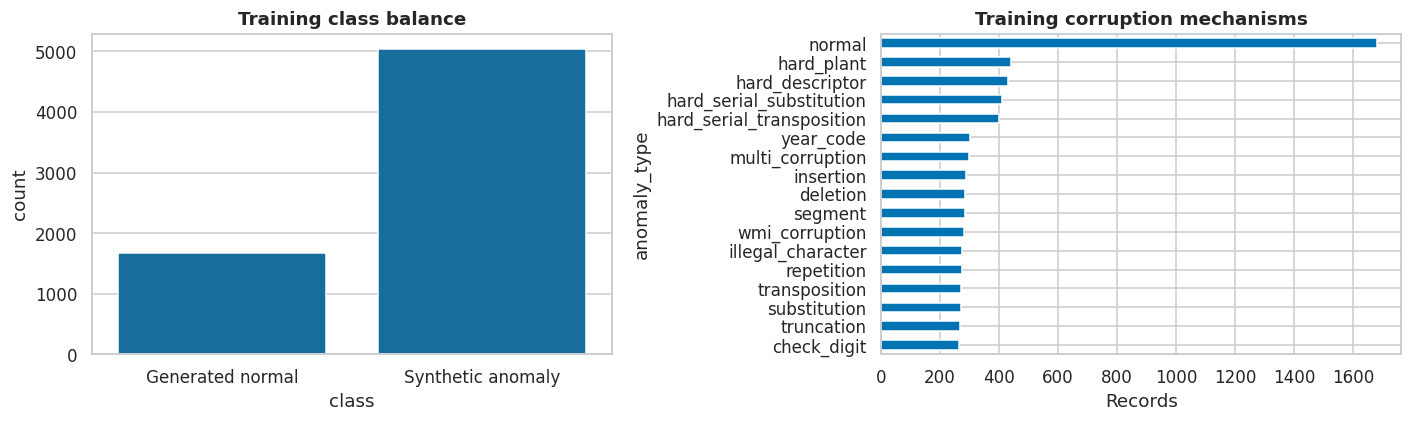

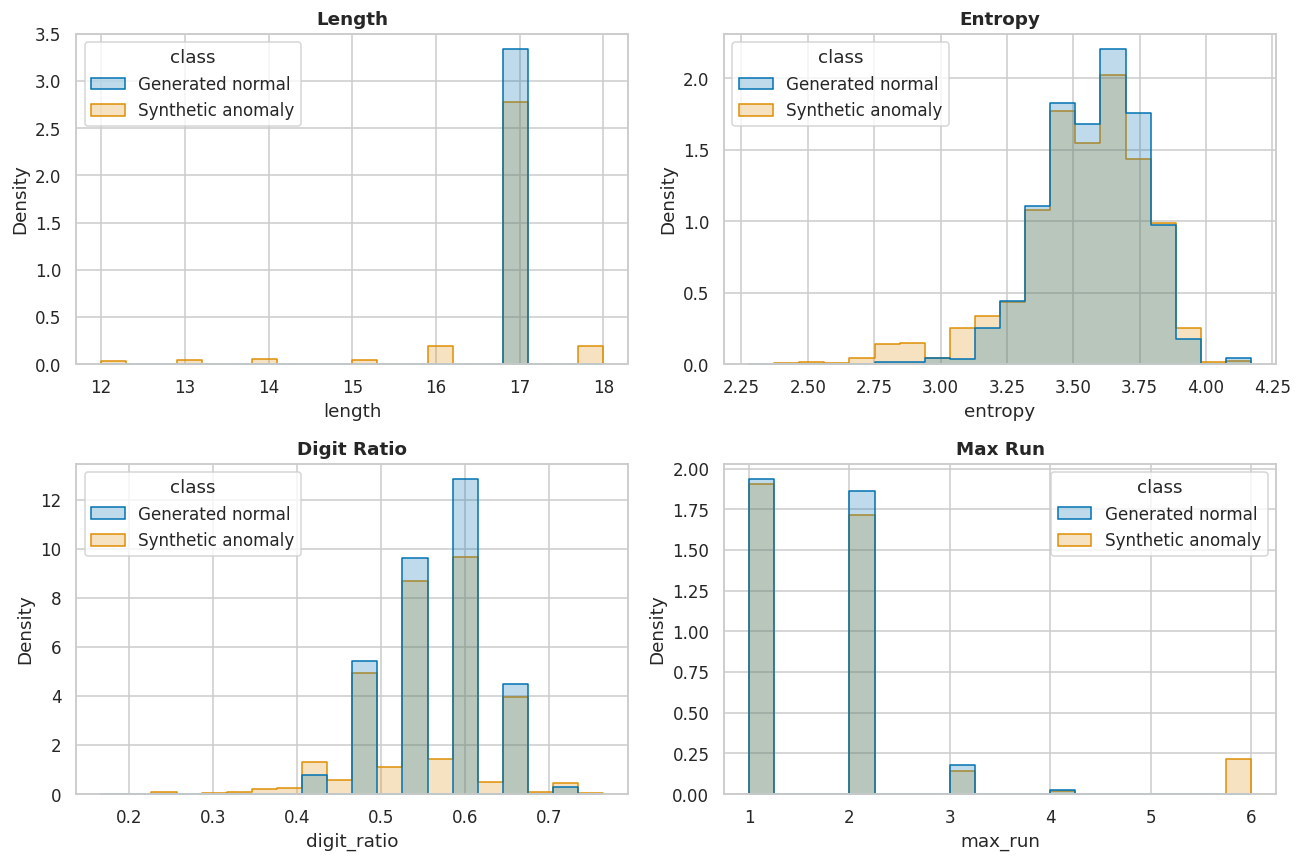

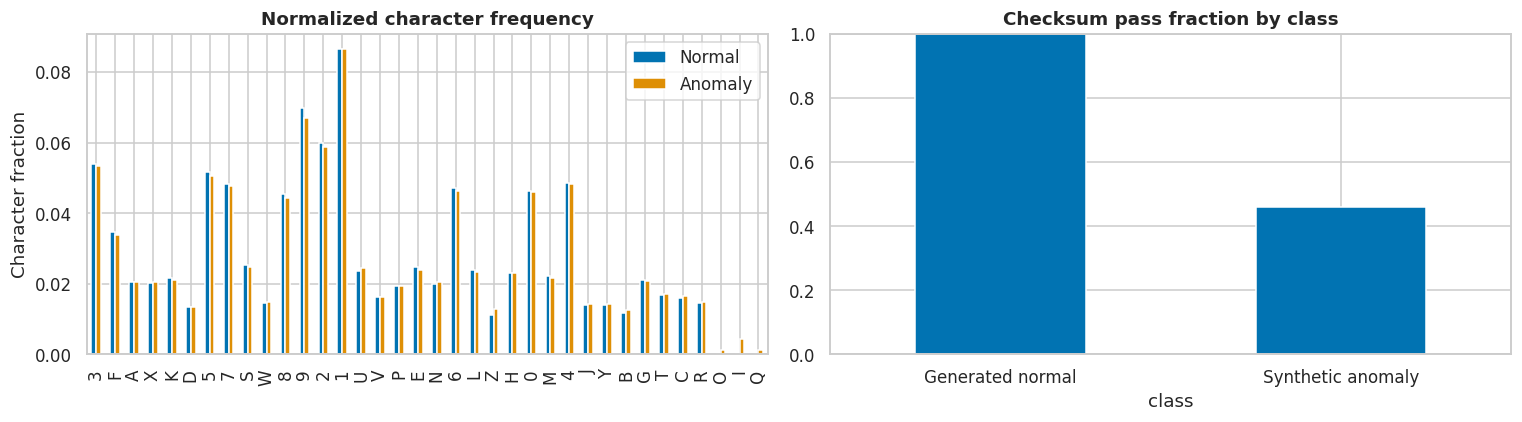

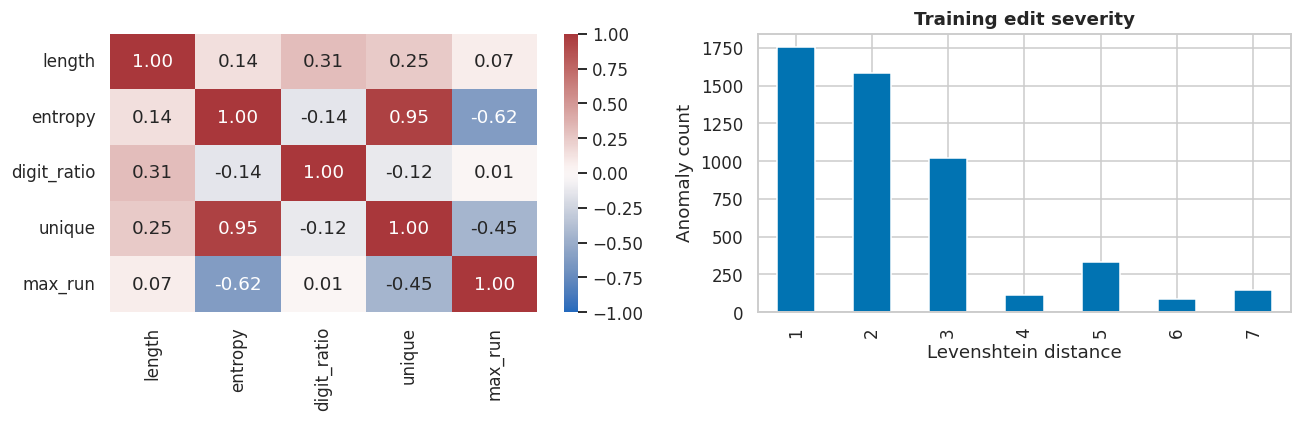

The class plot reflects the designed **75%** anomaly prevalence, not field prevalence. **29.9%** of all training rows are rule-passing transformed examples. Length exposes easy cases; entropy, runs and character distributions show how the corruption process changes the synthetic population. Correlations describe redundant measurements, not causes. Checksum pass rates show why a separate hard evaluation is necessary.

In [10]:
def basic_features(vin):
    n=len(vin); counts=Counter(vin); denominator=max(n,1)
    digits=sum(c in DIGITS for c in vin); letters=sum(c in LETTERS for c in vin)
    runs=[len(list(g)) for _,g in groupby(vin)]
    entropy=-sum((v/denominator)*np.log2(v/denominator) for v in counts.values())
    result=dict(length=n,digits=digits,letters=letters,digit_ratio=digits/denominator,
        letter_ratio=letters/denominator,unique=len(counts),repeated=n-len(counts),
        max_run=max(runs,default=0),adjacent_duplicates=sum(a==b for a,b in zip(vin,vin[1:])),
        entropy=entropy)
    for k in (2,3):
        grams=Counter(vin[i:i+k] for i in range(max(0,n-k+1)))
        result[f"repeated_{k}grams"]=sum(max(0,v-1) for v in grams.values())
    result.update({f"frequency_{c}":counts.get(c,0)/denominator for c in ALPHABET})
    return result

def domain_features(vin, frequencies):
    r=VINValidator.validate(vin)
    return dict(length_invalid=float(not r["length_ok"]),illegal_count=sum(c not in ALPHABET for c in vin),
        checksum_invalid=float(r["check_digit"]!="PASS"),
        year_invalid=float(len(vin)!=17 or vin[9] not in YEAR_CODES),
        numeric_suffix_invalid=float(len(vin)!=17 or not all(c in DIGITS for c in vin[-5:])),
        low_volume_scope=float(r["out_of_scope"]),reference_missing=float(not r["reference_present"]),
        wmi_train_frequency=frequencies.get(vin[:3],0.0),
        descriptor_digit_ratio=sum(c in DIGITS for c in vin[3:8])/5,
        position7_alpha=float(len(vin)>6 and vin[6] in LETTERS))

class VINFeatureExtractor(BaseEstimator, TransformerMixin):
    """Sparse engineered features; fit receives only VIN strings and optional binary labels."""
    def __init__(self, mode="combined", max_ngrams=2500):
        self.mode=mode; self.max_ngrams=max_ngrams
    def dictionaries(self, values):
        rows=[]
        for raw in values:
            vin=normalize_vin(raw); row={}
            if self.mode in ("basic","combined"):
                row.update({"basic_"+k:v for k,v in basic_features(vin).items()})
            if self.mode in ("domain","combined"):
                row.update({"domain_"+k:v for k,v in domain_features(vin,self.wmi_frequencies_).items()})
                row["ref_country"]=WMI_INFO.get(vin[:3],{}).get("Country","UNKNOWN")
                row["ref_manufacturer"]=WMI_INFO.get(vin[:3],{}).get("Name","UNKNOWN")
            if self.mode=="combined":
                row.update({f"position_{i+1:02d}":vin[i] if i<len(vin) else "<MISSING>" for i in range(18)})
            rows.append(row)
        return rows
    def fit(self, X, y=None):
        values=np.asarray(X,dtype=object)
        normal=values if y is None else values[np.asarray(y)==0]
        counts=Counter(normalize_vin(v)[:3] for v in normal)
        self.wmi_frequencies_={w:n/max(len(normal),1) for w,n in counts.items()}
        if self.mode!="ngrams":
            self.vectorizer_=DictVectorizer(sparse=True, dtype=np.float32)
            self.vectorizer_.fit(self.dictionaries(values))
        if self.mode in ("ngrams","combined"):
            self.ngrams_=TfidfVectorizer(analyzer="char",ngram_range=(2,3),lowercase=False,
                max_features=self.max_ngrams,sublinear_tf=True,dtype=np.float32)
            self.ngrams_.fit([normalize_vin(v) for v in values])
        return self
    def transform(self, X):
        values=list(X); blocks=[]
        if self.mode!="ngrams": blocks.append(self.vectorizer_.transform(self.dictionaries(values)))
        if self.mode in ("ngrams","combined"):
            blocks.append(self.ngrams_.transform([normalize_vin(v) for v in values]))
        return sp.hstack(blocks,format="csr",dtype=np.float32)
    def get_feature_names_out(self, input_features=None):
        names=[]
        if self.mode!="ngrams": names.extend(self.vectorizer_.get_feature_names_out())
        if self.mode in ("ngrams","combined"):
            names.extend("ngram_"+x for x in self.ngrams_.get_feature_names_out())
        return np.asarray(names,dtype=object)

eda=pd.DataFrame([basic_features(v) for v in train.vin])
eda["class"]=train.label.map({0:"Generated normal",1:"Synthetic anomaly"})
eda["check_pass"]=train.vin.map(lambda v:VINValidator.validate(v)["check_digit"]=="PASS")
fig, axes=plt.subplots(1,2,figsize=(13,4))
sns.countplot(data=eda,x="class",ax=axes[0]); axes[0].set_title("Training class balance")
train.anomaly_type.value_counts().sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Training corruption mechanisms"); axes[1].set_xlabel("Records")
finish_plot("training_class_and_type")
fig, axes=plt.subplots(2,2,figsize=(12,8))
for ax,feature in zip(axes.flat,["length","entropy","digit_ratio","max_run"]):
    sns.histplot(data=eda,x=feature,hue="class",stat="density",common_norm=False,
                 element="step",bins=20,ax=ax)
    ax.set_title(feature.replace("_"," ").title())
finish_plot("training_feature_distributions")
fig, axes=plt.subplots(1,2,figsize=(14,4))
pd.DataFrame({name:Counter("".join(train.loc[train.label.eq(label),"vin"]))
    for name,label in [("Normal",0),("Anomaly",1)]}).fillna(0).pipe(lambda d:d/d.sum()).plot.bar(ax=axes[0])
axes[0].set_title("Normalized character frequency"); axes[0].set_ylabel("Character fraction")
eda.groupby("class").check_pass.mean().plot.bar(ax=axes[1],rot=0,ylim=(0,1))
axes[1].set_title("Checksum pass fraction by class")
finish_plot("training_characters_checksum")
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.heatmap(eda[["length","entropy","digit_ratio","unique","max_run"]].corr(),
            vmin=-1,vmax=1,cmap="vlag",annot=True,fmt=".2f",ax=axes[0])
train.loc[train.label.eq(1),"edit_distance"].value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set(title="Training edit severity",xlabel="Levenshtein distance",ylabel="Anomaly count")
finish_plot("training_correlations_severity")
display(Markdown(f"The class plot reflects the designed **{train.label.mean():.0%}** anomaly prevalence, "
    f"not field prevalence. **{(train.difficulty=='hard').mean():.1%}** of all training rows are rule-passing "
    "transformed examples. Length exposes easy cases; entropy, runs and character distributions show "
    "how the corruption process changes the synthetic population. Correlations describe redundant "
    "measurements, not causes. Checksum pass rates show why a separate hard evaluation is necessary."))


## 16. Deterministic baseline

Two rule policies are retained: syntax/checksum only, and syntax plus limited-reference
coverage. The latter marks reference absence as suspicious, without claiming invalidity.
The combined supervised representation includes rules as features; “ML-only” later means
model inference without a hard rule override. The basic/n-gram ablations provide genuinely
rule-free comparisons. No claim that ML independently discovered VIN rules is made.
An always-anomalous baseline also contextualizes F1: a high anomaly prevalence can reward
flagging nearly everything. A high F1 with a high normal false-positive rate is not operational success.


In [11]:
def metrics(y, scores, threshold):
    y=np.asarray(y); scores=np.asarray(scores); prediction=(scores>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,prediction,labels=[0,1]).ravel()
    return dict(accuracy=accuracy_score(y,prediction),precision=precision_score(y,prediction,zero_division=0),
        recall=recall_score(y,prediction,zero_division=0),f1=f1_score(y,prediction,zero_division=0),
        roc_auc=roc_auc_score(y,scores) if len(np.unique(y))==2 else np.nan,
        pr_auc=average_precision_score(y,scores) if len(np.unique(y))==2 else np.nan,
        false_positive_rate=fp/max(fp+tn,1),false_negative_rate=fn/max(fn+tp,1),
        tn=int(tn),fp=int(fp),fn=int(fn),tp=int(tp),n=len(y))

def choose_threshold(y,scores):
    """Maximize validation F1; ties favor the higher (more conservative) threshold."""
    precision,recall,thresholds=precision_recall_curve(y,scores)
    f=2*precision[:-1]*recall[:-1]/np.maximum(precision[:-1]+recall[:-1],1e-12)
    assert len(f)>0
    index=np.flatnonzero(np.isclose(f,f.max()))[-1]
    return float(thresholds[index])

rule_validation={name:metrics(selection.label,[rules_score(v,policy) for v in selection.vin],.5)
    for name,policy in [("Rules syntax",False),("Rules + reference",True)]}
display(pd.DataFrame(rule_validation).T)


,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,tn,fp,fn,tp,n
Rules syntax,0.655556,1.0,0.540741,0.701923,0.770370,0.885185,0.0,0.459259,180.0,0.0,248.0,292.0,720.0
Rules + reference,0.697222,1.0,0.596296,0.747100,0.798148,0.899074,0.0,0.403704,180.0,0.0,218.0,322.0,720.0


## 17. Logistic Regression · 18. Random Forest · 19. XGBoost

Logistic Regression uses sparse scaling and regularization. Random Forest captures nonlinear
interactions and uses balanced class weights. XGBoost uses histogram trees and a class weight
computed from training only. Six bounded candidates (two per family) form the tuning budget.
Each candidate includes its own fitted feature pipeline. Only the selection validation subset
chooses hyperparameters, thresholds and family winners; the calibration subset is reserved.

### Computationally bounded hyperparameter tuning

This is a fixed holdout search, not cross-validation. It is intentionally modest and may be
noisy for rare mechanisms. The final test is not used to expand the grid or change features.
The table reports validation performance; it must not be mistaken for the final estimate.


In [12]:
def make_supervised(family, parameter, mode="combined"):
    steps=[("features",VINFeatureExtractor(mode=mode))]
    if family=="Logistic Regression":
        steps.extend([("scale",StandardScaler(with_mean=False)),
            ("model",LogisticRegression(C=parameter,max_iter=1800,solver="liblinear",
                class_weight="balanced",random_state=RANDOM_STATE))])
    elif family=="Random Forest":
        steps.append(("model",RandomForestClassifier(n_estimators=80 if QUICK_MODE else 160,
            max_depth=parameter,min_samples_leaf=2,class_weight="balanced",max_features="sqrt",
            n_jobs=N_JOBS,random_state=RANDOM_STATE)))
    elif family=="XGBoost":
        steps.append(("model",XGBClassifier(n_estimators=90 if QUICK_MODE else 180,max_depth=parameter,
            learning_rate=.08,subsample=.85,colsample_bytree=.85,reg_lambda=2,
            tree_method="hist",eval_metric="logloss",n_jobs=N_JOBS,random_state=RANDOM_STATE,
            scale_pos_weight=float((train.label==0).sum()/max((train.label==1).sum(),1)))))
    else: raise ValueError(family)
    return Pipeline(steps)

supervised={}; sup_thresholds={}; tuning_rows=[]
grids={"Logistic Regression":[.1,1.0],"Random Forest":[12,None],"XGBoost":[3,5]}
for family,grid in grids.items():
    winner=None; best_key=(-np.inf,-np.inf)
    for parameter in grid:
        start=time.perf_counter()
        pipeline=make_supervised(family,parameter)
        pipeline.fit(train.vin.to_numpy(),train.label.to_numpy())
        scores=pipeline.predict_proba(selection.vin.to_numpy())[:,1]
        threshold=choose_threshold(selection.label,scores)
        report=metrics(selection.label,scores,threshold)
        tuning_rows.append(dict(family=family,parameter=str(parameter),threshold=threshold,
            seconds=time.perf_counter()-start,**report))
        key=(report["f1"],report["pr_auc"])
        if key>best_key:
            winner=(pipeline,threshold,parameter); best_key=key
        logging.info("%s %s validation F1 %.3f",family,parameter,report["f1"])
    supervised[family]=winner[0]; sup_thresholds[family]=winner[1]
tuning=pd.DataFrame(tuning_rows)
display(tuning[["family","parameter","f1","recall","pr_auc","seconds"]])
tuning.to_csv(OUT / "validation_tuning.csv",index=False)
feature_names=supervised["Logistic Regression"].named_steps["features"].get_feature_names_out()
feature_test=supervised["Logistic Regression"].named_steps["features"].transform(train.vin.iloc[:3])
assert feature_test.shape[1]==len(feature_names) and np.isfinite(feature_test.data).all()
assert not any(any(token in name for token in ("group_id","edit_distance","anomaly_type","partition"))
               for name in feature_names)
pd.Series(feature_names,name="feature").to_csv(OUT / "feature_names.csv",index=False)


,family,parameter,f1,recall,pr_auc,seconds
0,Logistic Regression,0.1,0.857143,1.000000,0.945556,8.809428
1,Logistic Regression,1.0,0.858513,0.994444,0.940352,11.358527
2,Random Forest,12,0.857143,1.000000,0.951171,5.027577
3,Random Forest,None,0.864815,0.864815,0.958207,16.343679
4,XGBoost,3,0.858995,0.981481,0.955984,7.339680
5,XGBoost,5,0.864909,0.972222,0.958864,12.138389


## 20. Isolation Forest · 21. One-Class SVM

These detectors fit only normal training examples. Their training objective never sees
corruption labels, but validation-labeled threshold selection makes the *operating policy*
semi-supervised. Isolation Forest uses compact statistical/domain features. One-Class SVM
uses the same standardized representation and a bounded normal sample to contain its cost.
Normal-training constant features have scale 1; out-of-support malformed values can then
produce large distances. This is a deliberate, disclosed source of easy-case performance.


In [13]:
class CompactRepresentation:
    """Numeric representation for normal-only models; no descriptor-template access."""
    def fit(self, values):
        values=list(values); count=Counter(v[:3] for v in values)
        self.frequencies={w:n/len(values) for w,n in count.items()}
        self.names=list(self.one(values[0]))
        self.scaler=StandardScaler().fit(self.raw(values))
        return self
    def one(self,vin):
        return {**{"basic_"+k:v for k,v in basic_features(vin).items()},
                **{"domain_"+k:v for k,v in domain_features(vin,self.frequencies).items()}}
    def raw(self,values):
        return np.asarray([list(self.one(v).values()) for v in values],dtype=np.float32)
    def transform(self,values):
        return self.scaler.transform(self.raw(values)).astype(np.float32)

normal_train=train.loc[train.label.eq(0),"vin"].to_numpy()
compact=CompactRepresentation().fit(normal_train)
Z_normal=compact.transform(normal_train)
Z_selection=compact.transform(selection.vin)
isolation=IsolationForest(n_estimators=120 if QUICK_MODE else 240,max_samples=min(256,len(normal_train)),
    contamination="auto",n_jobs=N_JOBS,random_state=RANDOM_STATE).fit(Z_normal)
svm_rng=np.random.default_rng(RANDOM_STATE)
svm_indices=svm_rng.choice(len(Z_normal),min(len(Z_normal),1600),replace=False)
oneclass=OneClassSVM(kernel="rbf",gamma="scale",nu=.05,cache_size=256).fit(Z_normal[svm_indices])
print("Normal-only training rows:",len(normal_train),"; One-Class SVM rows:",len(svm_indices))


Normal-only training rows: 1680 ; One-Class SVM rows: 1600


## 22. Compact neural autoencoder

A 48→12 bottleneck network reconstructs the standardized compact numeric representation.
It does not reconstruct the VIN text, and may miss sequence-level anomalies. Training uses
only normal training records; early stopping monitors **normal calibration-validation**
reconstruction loss. The best weights are restored. A separate selection-validation subset
later supplies the decision threshold. Test reconstruction error is not consulted here.


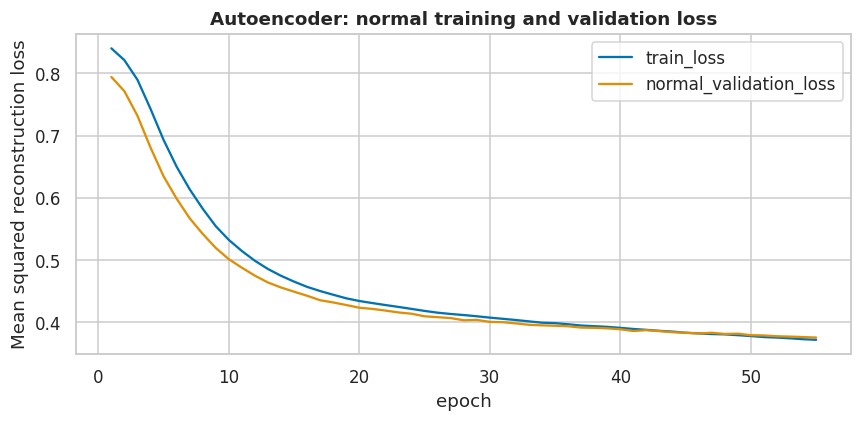

Training ran for **55** epochs; restored normal-validation loss is **0.3757**. A small gap suggests similar compact-feature distributions; it does not establish capacity to detect novel mechanisms or realistic fraud.

In [14]:
class VINAutoencoder(torch.nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.network=torch.nn.Sequential(torch.nn.Linear(input_dim,48),torch.nn.ReLU(),
            torch.nn.Linear(48,12),torch.nn.ReLU(),torch.nn.Linear(12,48),torch.nn.ReLU(),
            torch.nn.Linear(48,input_dim))
    def forward(self,x): return self.network(x)

autoencoder=VINAutoencoder(Z_normal.shape[1]).to(DEVICE)
optimizer=torch.optim.Adam(autoencoder.parameters(),lr=1e-3,weight_decay=1e-5)
loader=torch.utils.data.DataLoader(torch.from_numpy(Z_normal),batch_size=128,shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),num_workers=0)
Z_ae_val=torch.from_numpy(compact.transform(cal.loc[cal.label.eq(0),"vin"])).to(DEVICE)
history=[]; best_loss=float("inf"); stale=0; best_state=None
for epoch in range(AE_EPOCHS):
    autoencoder.train(); total=0; n=0
    for batch in loader:
        batch=batch.to(DEVICE); optimizer.zero_grad()
        loss=torch.nn.functional.mse_loss(autoencoder(batch),batch)
        loss.backward(); optimizer.step()
        total+=float(loss.detach().cpu())*len(batch); n+=len(batch)
    autoencoder.eval()
    with torch.no_grad():
        val_loss=float(torch.nn.functional.mse_loss(autoencoder(Z_ae_val),Z_ae_val).cpu())
    history.append(dict(epoch=epoch+1,train_loss=total/n,normal_validation_loss=val_loss))
    if val_loss<best_loss-1e-5:
        best_loss=val_loss; best_state=deepcopy(autoencoder.state_dict()); stale=0
    else: stale+=1
    if stale>=AE_PATIENCE: break
autoencoder.load_state_dict(best_state); autoencoder.eval()

def ae_scores(values):
    """Batched mean-squared reconstruction error; higher means more anomalous."""
    z=compact.transform(values); chunks=[]
    with torch.no_grad():
        for start in range(0,len(z),512):
            batch=torch.from_numpy(z[start:start+512]).to(DEVICE)
            chunks.append(((autoencoder(batch)-batch)**2).mean(dim=1).cpu().numpy())
    return np.concatenate(chunks)

pd.DataFrame(history).set_index("epoch").plot(figsize=(8,4),ylabel="Mean squared reconstruction loss",
    title="Autoencoder: normal training and validation loss")
finish_plot("autoencoder_learning_curve")
display(Markdown(f"Training ran for **{len(history)}** epochs; restored normal-validation loss "
    f"is **{best_loss:.4f}**. A small gap suggests similar compact-feature distributions; "
    "it does not establish capacity to detect novel mechanisms or realistic fraud."))


## 23. Hyperparameter search results

The six-candidate search above has completed. Its `validation_tuning.csv` records each
parameter choice, runtime and selection-validation metrics. Family winners are retained;
normal-only model settings were predeclared rather than tuned against test outcomes.

## 24. Validation selection, ablation and novel-experiment preparation

Higher scores mean more anomalous for all detectors (the sklearn decision scores are negated).
Thresholds maximize selection-validation F1. The chosen supervised family maximizes validation
F1, breaking ties by average precision; detectors use the same rule. Average precision is
reported as PR-AUC throughout; it is not trapezoidal integration.

Four Logistic Regression ablations use statistical features, n-grams, domain features, and
the combined representation. They retain the predeclared C=0.1 setting and independent
training-only preprocessing. Ablations diagnose signal sources and do not replace the
already specified selection procedure.


In [15]:
def detector_scores(name,values):
    if name=="Isolation Forest": return -isolation.score_samples(compact.transform(values))
    if name=="One-Class SVM": return -oneclass.decision_function(compact.transform(values))
    if name=="Autoencoder": return ae_scores(values)
    raise ValueError(name)

DETECTORS=["Isolation Forest","One-Class SVM","Autoencoder"]
detector_thresholds={}; validation_rows=[]
for name,pipeline in supervised.items():
    score=pipeline.predict_proba(selection.vin.to_numpy())[:,1]
    validation_rows.append(dict(model=name,paradigm="supervised",**metrics(selection.label,score,sup_thresholds[name])))
for name in DETECTORS:
    score=detector_scores(name,selection.vin)
    detector_thresholds[name]=choose_threshold(selection.label,score)
    validation_rows.append(dict(model=name,paradigm="normal-only",**metrics(selection.label,score,detector_thresholds[name])))
validation_comparison=pd.DataFrame(validation_rows).set_index("model")
best_supervised=validation_comparison.query("paradigm=='supervised'").sort_values(["f1","pr_auc"],ascending=False).index[0]
best_detector=validation_comparison.query("paradigm=='normal-only'").sort_values(["f1","pr_auc"],ascending=False).index[0]
display(validation_comparison)
print("Selected using validation only:",best_supervised,"and",best_detector)
ablations={}; ablation_thresholds={}
for mode in ["basic","ngrams","domain","combined"]:
    pipe=make_supervised("Logistic Regression",.1,mode)
    pipe.fit(train.vin.to_numpy(),train.label.to_numpy())
    ablations[mode]=pipe
    ablation_thresholds[mode]=choose_threshold(selection.label,pipe.predict_proba(selection.vin.to_numpy())[:,1])
validation_comparison.to_csv(OUT / "validation_model_selection.csv")


,paradigm,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,tn,fp,fn,tp,n
model,,,,,,,,,,,,,,
Logistic Regression,supervised,0.754167,0.755274,0.994444,0.858513,0.818220,0.940352,0.966667,0.005556,6,174,3,537,720
Random Forest,supervised,0.797222,0.864815,0.864815,0.864815,0.861718,0.958207,0.405556,0.135185,107,73,73,467,720
XGBoost,supervised,0.772222,0.778932,0.972222,0.864909,0.864552,0.958864,0.827778,0.027778,31,149,15,525,720
Isolation Forest,normal-only,0.750000,0.750000,1.000000,0.857143,0.597984,0.828899,1.000000,0.000000,0,180,0,540,720
One-Class SVM,normal-only,0.750000,0.750000,1.000000,0.857143,0.677582,0.871760,1.000000,0.000000,0,180,0,540,720
Autoencoder,normal-only,0.754167,0.753138,1.000000,0.859189,0.665967,0.862875,0.983333,0.000000,3,177,0,540,720


Selected using validation only: XGBoost and Autoencoder


### 24.1 Probability calibration before the test lock

A sigmoid calibrator fits only the calibration-validation labels for each supervised family.
It maps the clipped logit of its raw score to a calibrated benchmark probability. Raw versus
calibrated Brier score is compared on selection-validation; calibration is retained only
when Brier improves. Thresholds are then reselected on that same selection subset. This
reuse increases validation optimism, which is why final test metrics are reported separately.
The supervised family was selected before calibration and is not reselected afterward.

Even well-calibrated benchmark probabilities reflect this generator's 75% anomaly prevalence,
not a real-world probability that a vehicle is authentic. Calibration cannot correct unknown
fraud prevalence or synthetic-to-real distribution shift.


In [16]:
def logits(probability):
    p=np.clip(probability,1e-6,1-1e-6)
    return np.log(p/(1-p)).reshape(-1,1)

calibrators={}; use_calibration={}; calibration_validation=[]
for name,pipeline in supervised.items():
    raw_cal=pipeline.predict_proba(cal.vin.to_numpy())[:,1]
    calibrator=LogisticRegression(C=1,max_iter=500,random_state=RANDOM_STATE).fit(logits(raw_cal),cal.label)
    raw_select=pipeline.predict_proba(selection.vin.to_numpy())[:,1]
    adjusted=calibrator.predict_proba(logits(raw_select))[:,1]
    before=brier_score_loss(selection.label,raw_select); after=brier_score_loss(selection.label,adjusted)
    calibrators[name]=calibrator; use_calibration[name]=after<before
    sup_thresholds[name]=choose_threshold(selection.label,adjusted if after<before else raw_select)
    calibration_validation.append(dict(model=name,raw_brier=before,calibrated_brier=after,retained=after<before))
display(pd.DataFrame(calibration_validation))

def supervised_scores(name,values,raw=False):
    score=supervised[name].predict_proba(np.asarray(values,dtype=object))[:,1]
    return calibrators[name].predict_proba(logits(score))[:,1] if use_calibration[name] and not raw else score

# Predeclared hybrid: any deterministic flag -> high; both learned flags -> high;
# one learned flag -> moderate; none -> low. Moderate and high count as detected.
def hybrid_scores(values):
    values=list(values)
    rules=np.array([rules_score(v) for v in values])
    sup=supervised_scores(best_supervised,values)>=sup_thresholds[best_supervised]
    uns=detector_scores(best_detector,values)>=detector_thresholds[best_detector]
    return np.where(rules.astype(bool)|(sup & uns),2,np.where(sup|uns,1,0))

operating_validation={
    best_supervised:metrics(selection.label,supervised_scores(best_supervised,selection.vin),sup_thresholds[best_supervised]),
    "Hybrid":metrics(selection.label,hybrid_scores(selection.vin),.5)}
pd.DataFrame(operating_validation).T.to_csv(OUT / "final_validation_operating_points.csv")

# Two predeclared holdouts: no held type is used for fitting, thresholding or model selection.
# Fixed LR hyperparameters and normal-only detectors avoid selecting a family using that type.
NOVEL_TYPES=["hard_descriptor","repetition"]
novel_models={}; novel_thresholds={}; novel_detector_thresholds={}
for held_type in NOVEL_TYPES:
    known_train=train[train.anomaly_type.ne(held_type)]
    known_val=selection[selection.anomaly_type.ne(held_type)]
    assert held_type not in set(known_train.anomaly_type) and held_type not in set(known_val.anomaly_type)
    pipe=make_supervised("Logistic Regression",.1)
    pipe.fit(known_train.vin.to_numpy(),known_train.label.to_numpy())
    novel_models[held_type]=pipe
    novel_thresholds[held_type]=choose_threshold(known_val.label,pipe.predict_proba(known_val.vin.to_numpy())[:,1])
    novel_detector_thresholds[held_type]={name:choose_threshold(known_val.label,detector_scores(name,known_val.vin))
                                         for name in DETECTORS}

LOCK=dict(best_supervised=best_supervised,best_detector=best_detector,
    supervised_thresholds=sup_thresholds,detector_thresholds=detector_thresholds,
    calibration_retained=use_calibration,ablation_thresholds=ablation_thresholds,
    novel_types=NOVEL_TYPES,novel_thresholds=novel_thresholds,novel_detector_thresholds=novel_detector_thresholds,
    hybrid_policy="rule OR supervised OR detector; high if rule OR both learned flags",
    locked_utc=datetime.now(timezone.utc).isoformat())
save_json(LOCK,"experiment_lock.json")
print("All candidates, calibration choices and thresholds locked. No fitting follows this boundary.")


,model,raw_brier,calibrated_brier,retained
0,Logistic Regression,0.217846,0.154569,True
1,Random Forest,0.131372,0.132714,False
2,XGBoost,0.135738,0.122363,True


All candidates, calibration choices and thresholds locked. No fitting follows this boundary.


## 25. FINAL LOCKED TEST SET EVALUATION

**The test outcomes are accessed for evaluation for the first time below.** No hyperparameter,
feature, threshold, calibrator or model-selection decision may change after this cell.
Subsequent plots are fixed diagnostics from these same predictions, not new optimization.

Rows from a source are correlated. A group bootstrap supplies uncertainty for the selected
supervised and hybrid F1 scores. Precision/PR curves reflect the synthetic class balance.
Rules and hybrid scores are discrete, so their ranking curves are coarse; their operating
points and error counts are more useful than interpreting them as probabilities.


,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,tn,fp,fn,tp,n
model,,,,,,,,,,,,,
Logistic Regression,0.7514,0.7698,0.9537,0.8519,0.8045,0.9280,0.8556,0.0463,52,308,50,1030,1440
Random Forest,0.7799,0.8582,0.8463,0.8522,0.8603,0.9572,0.4194,0.1537,209,151,166,914,1440
XGBoost,0.7576,0.7734,0.9574,0.8556,0.8541,0.9552,0.8417,0.0426,57,303,46,1034,1440
Isolation Forest,0.7500,0.7500,1.0000,0.8571,0.5847,0.8179,1.0000,0.0000,0,360,0,1080,1440
One-Class SVM,0.7493,0.7509,0.9963,0.8563,0.6637,0.8620,0.9917,0.0037,3,357,4,1076,1440
Autoencoder,0.7493,0.7502,0.9981,0.8566,0.6470,0.8498,0.9972,0.0019,1,359,2,1078,1440
Rules syntax,0.6451,1.0000,0.5269,0.6901,0.7634,0.8817,0.0000,0.4731,360,0,511,569,1440
Rules + reference,0.6903,1.0000,0.5870,0.7398,0.7935,0.8968,0.0000,0.4130,360,0,446,634,1440
Hybrid,0.7500,0.7500,1.0000,0.8571,0.5593,0.7729,1.0000,0.0000,0,360,0,1080,1440


,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,tn,fp,fn,tp,n
Always anomalous (no learning),0.75,0.75,1.0,0.857143,0.5,0.75,1.0,0.0,0.0,360.0,0.0,1080.0,1440.0


At the test anomaly prevalence of **75.0%**, flagging every row achieves F1 **0.857** and a **100% normal false-positive rate**. Use this no-learning baseline to avoid mistaking a high F1 for useful discrimination. No threshold is altered in response to this diagnostic.

95% source-group bootstrap F1 intervals: {'XGBoost': [0.8492307742719233, 0.8616274266831888], 'Hybrid': [0.8571428571428571, 0.8571428571428571]}


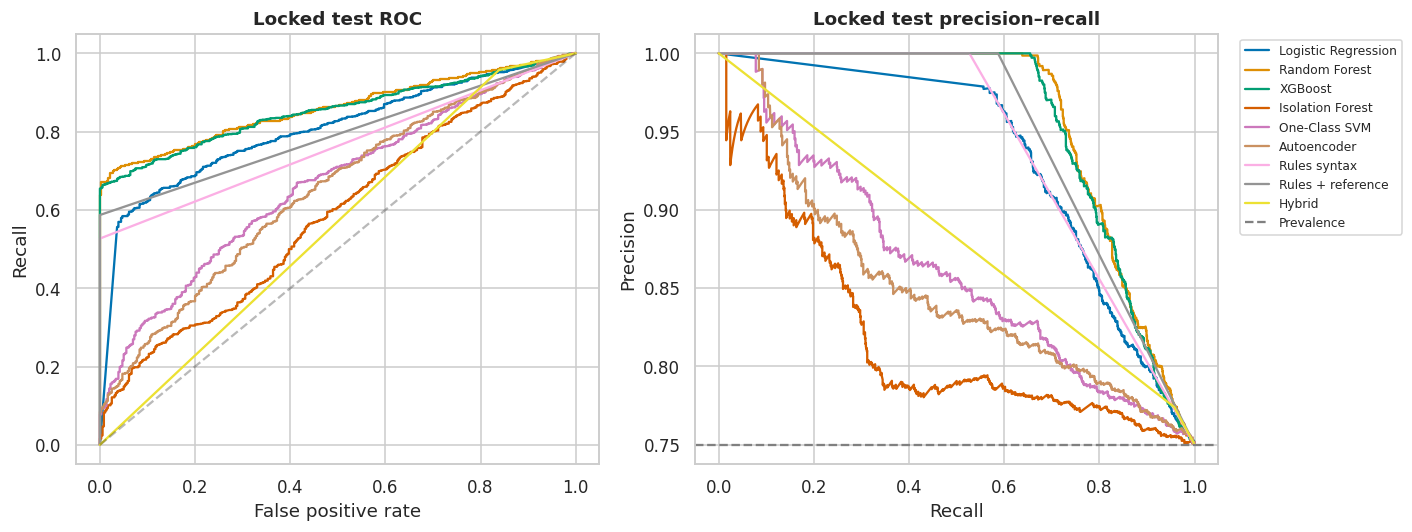

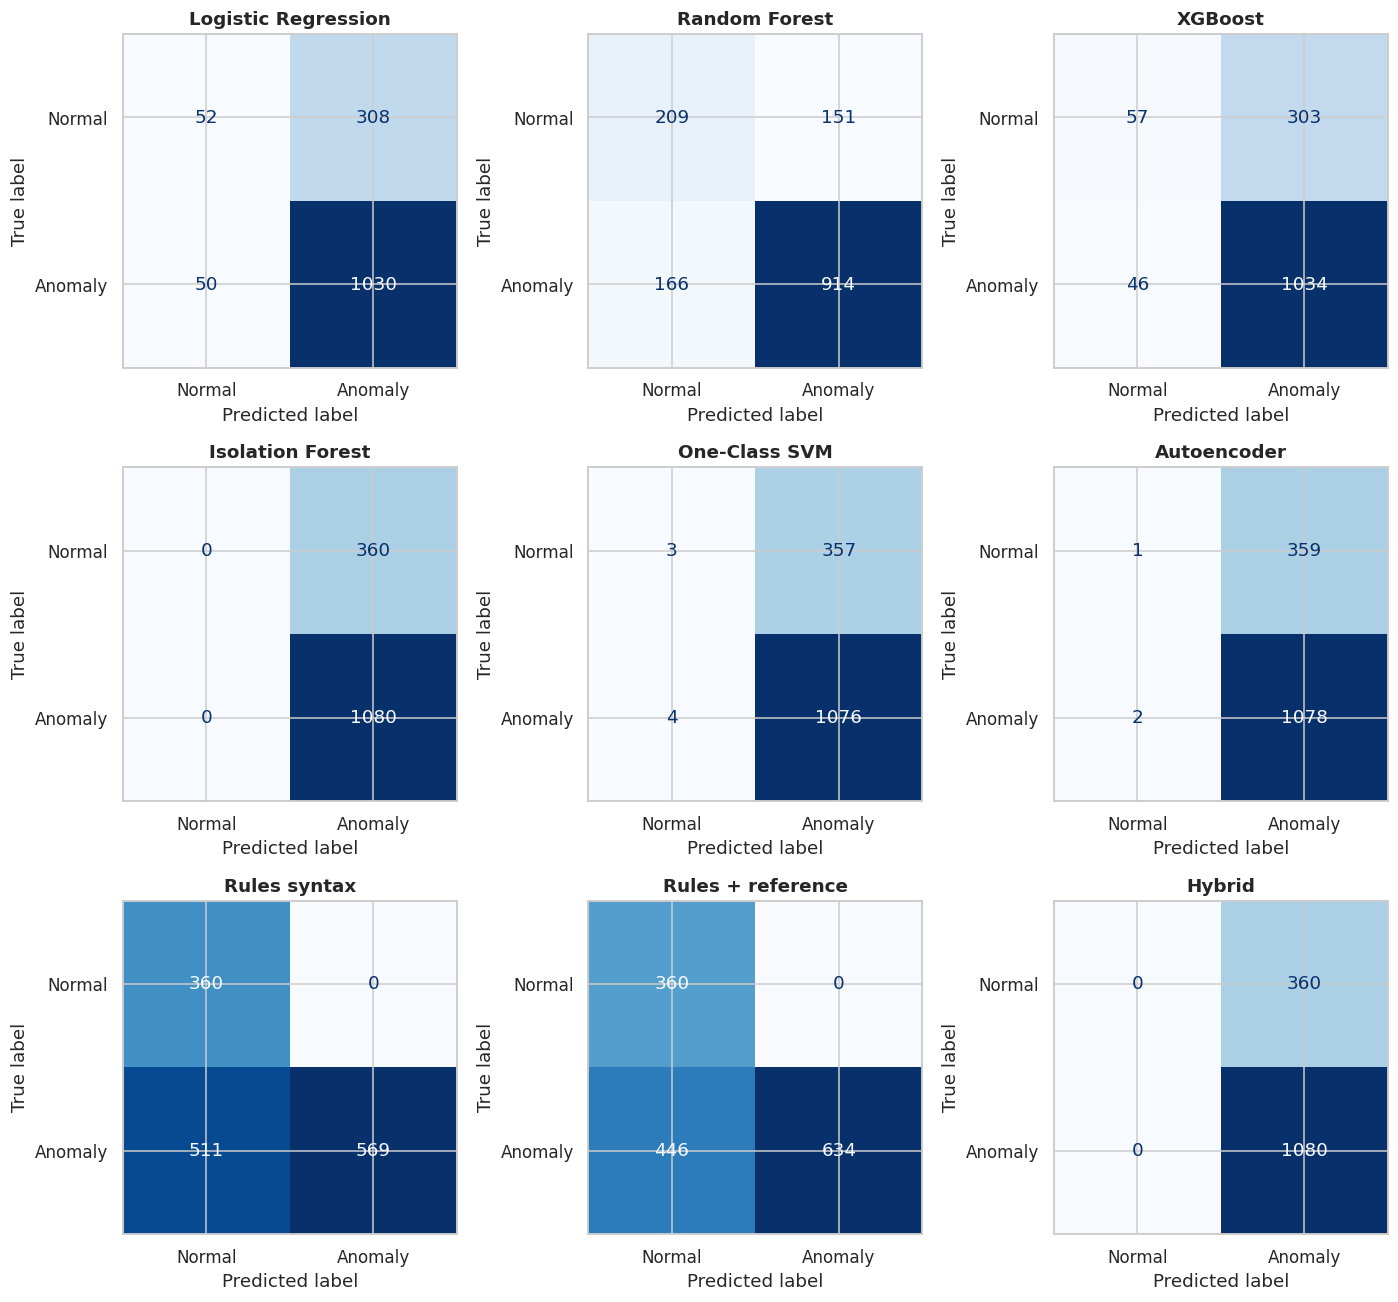

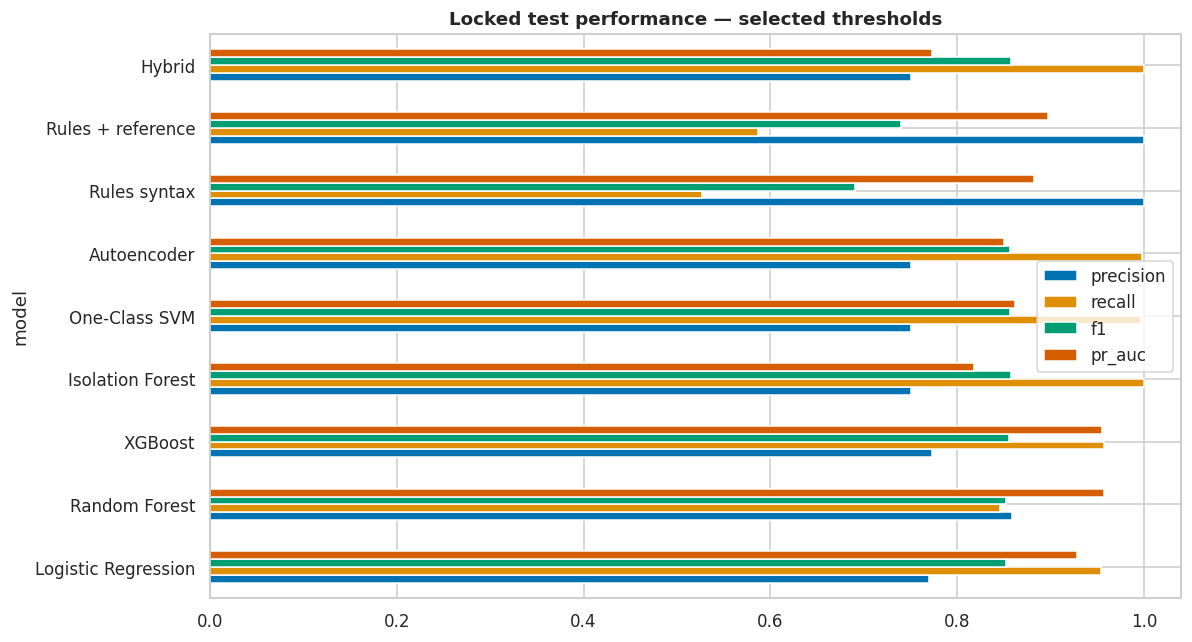

The validation-selected **XGBoost** has test F1 **0.856**, with **303 false positives** and **46 false negatives**. ROC displays ranking across false-positive rates; PR is more sensitive to anomaly prevalence. Confusion matrices expose the operating tradeoff obscured by accuracy. A higher aggregate score can still conceal failure on the rule-passing serial controls.

In [17]:
test=locked_test.copy()
test_scores={name:supervised_scores(name,test.vin) for name in supervised}
test_scores.update({name:detector_scores(name,test.vin) for name in DETECTORS})
test_scores["Rules syntax"]=np.array([rules_score(v,False) for v in test.vin])
test_scores["Rules + reference"]=np.array([rules_score(v,True) for v in test.vin])
test_scores["Hybrid"]=hybrid_scores(test.vin)
thresholds={**sup_thresholds,**detector_thresholds,"Rules syntax":.5,"Rules + reference":.5,"Hybrid":.5}
test_predictions={name:(score>=thresholds[name]).astype(int) for name,score in test_scores.items()}
comparison=pd.DataFrame([dict(model=name,**metrics(test.label,score,thresholds[name]))
    for name,score in test_scores.items()]).set_index("model")
display(comparison.round(4))
comparison.to_csv(OUT / "model_comparison.csv")
comparison.to_csv(OUT / "test_metrics.csv")
always_anomalous=metrics(test.label,np.ones(len(test)),.5)
display(pd.DataFrame({"Always anomalous (no learning)":always_anomalous}).T)
save_json(always_anomalous,"always_anomalous_baseline.json")
display(Markdown(f"At the test anomaly prevalence of **{test.label.mean():.1%}**, flagging every row "
    f"achieves F1 **{always_anomalous['f1']:.3f}** and a **100% normal false-positive rate**. "
    "Use this no-learning baseline to avoid mistaking a high F1 for useful discrimination. "
    "No threshold is altered in response to this diagnostic."))

def group_bootstrap_f1(y,prediction,groups,n_boot=250):
    """Resample entire source families, retaining their correlated descendants."""
    y=np.asarray(y); prediction=np.asarray(prediction); groups=np.asarray(groups)
    unique=np.unique(groups); indices=pd.DataFrame({"group":groups}).groupby("group").indices
    rng=np.random.default_rng(RANDOM_STATE+100); statistics=[]
    for _ in range(n_boot):
        rows=np.concatenate([indices[g] for g in rng.choice(unique,len(unique),replace=True)])
        statistics.append(f1_score(y[rows],prediction[rows],zero_division=0))
    return np.quantile(statistics,[.025,.975]).tolist()

intervals={name:group_bootstrap_f1(test.label,test_predictions[name],test.group_id)
           for name in (best_supervised,"Hybrid")}
print("95% source-group bootstrap F1 intervals:",intervals)
save_json(intervals,"group_bootstrap_intervals.json")
fig,axes=plt.subplots(1,2,figsize=(13,5))
for name,score in test_scores.items():
    fpr,tpr,_=roc_curve(test.label,score); axes[0].plot(fpr,tpr,label=name)
    p,r,_=precision_recall_curve(test.label,score); axes[1].plot(r,p,label=name)
axes[0].plot([0,1],[0,1],"k--",alpha=.3)
axes[0].set(title="Locked test ROC",xlabel="False positive rate",ylabel="Recall")
axes[1].axhline(test.label.mean(),ls="--",color="gray",label="Prevalence")
axes[1].set(title="Locked test precision–recall",xlabel="Recall",ylabel="Precision")
axes[1].legend(fontsize=8,bbox_to_anchor=(1.03,1))
finish_plot("test_roc_pr")
fig,axes=plt.subplots(3,3,figsize=(13,12))
for ax,(name,prediction) in zip(axes.flat,test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(test.label,prediction,labels=[0,1],
        display_labels=["Normal","Anomaly"],ax=ax,colorbar=False,cmap="Blues")
    ax.set_title(name)
finish_plot("test_confusion_matrices")
comparison[["precision","recall","f1","pr_auc"]].plot.barh(figsize=(11,6),xlim=(0,1.04))
plt.title("Locked test performance — selected thresholds")
finish_plot("test_model_comparison")
display(Markdown(f"The validation-selected **{best_supervised}** has test F1 "
    f"**{comparison.loc[best_supervised,'f1']:.3f}**, with "
    f"**{int(comparison.loc[best_supervised,'fp'])} false positives** and "
    f"**{int(comparison.loc[best_supervised,'fn'])} false negatives**. "
    "ROC displays ranking across false-positive rates; PR is more sensitive to anomaly prevalence. "
    "Confusion matrices expose the operating tradeoff obscured by accuracy. A higher aggregate "
    "score can still conceal failure on the rule-passing serial controls."))


## 26. Locked-test calibration diagnostics

Quantile bins show empirical anomaly frequency against score for raw and sigmoid-adjusted
versions. Both were fitted before the lock; plotting an unused calibrator here does not
authorize selecting it on the test. Brier scores are computed for every supervised model,
with the retained policy recorded. Small bins and correlated families limit interpretation.


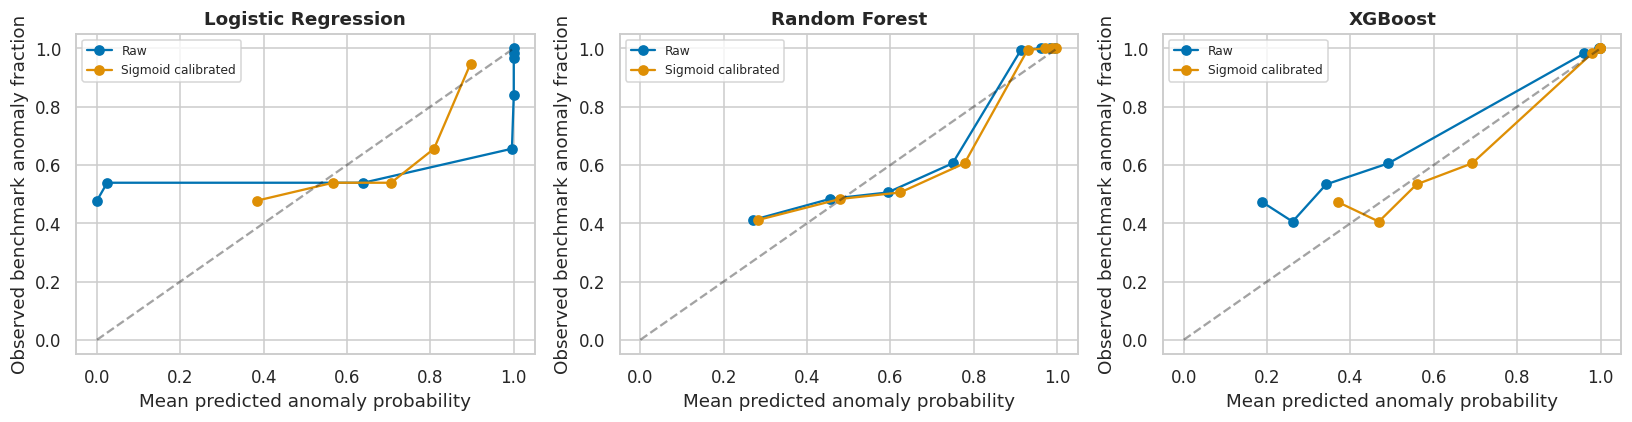

,model,raw_brier,calibrated_brier,deployed_brier,retained
0,Logistic Regression,0.234238,0.155056,0.155056,True
1,Random Forest,0.130600,0.131751,0.130600,False
2,XGBoost,0.143409,0.127183,0.127183,True


Points near the diagonal indicate calibration for this **synthetic evaluation population**. Use the retained column to identify the pre-test deployment choice. A sigmoid curve that looks better here is not adopted after seeing the test, and no score estimates physical authenticity.

In [18]:
calibration_test=[]
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(name,pipeline) in zip(axes,supervised.items()):
    raw=supervised_scores(name,test.vin,raw=True)
    adjusted=calibrators[name].predict_proba(logits(raw))[:,1]
    for label,score in [("Raw",raw),("Sigmoid calibrated",adjusted)]:
        actual,predicted=calibration_curve(test.label,score,n_bins=8,strategy="quantile")
        ax.plot(predicted,actual,"o-",label=label)
    ax.plot([0,1],[0,1],"k--",alpha=.4)
    ax.set(title=name,xlabel="Mean predicted anomaly probability",ylabel="Observed benchmark anomaly fraction")
    ax.legend(fontsize=8)
    calibration_test.append(dict(model=name,raw_brier=brier_score_loss(test.label,raw),
        calibrated_brier=brier_score_loss(test.label,adjusted),
        deployed_brier=brier_score_loss(test.label,test_scores[name]),retained=use_calibration[name]))
finish_plot("test_calibration")
calibration_metrics=pd.DataFrame(calibration_test)
display(calibration_metrics)
calibration_metrics.to_csv(OUT / "calibration_metrics.csv",index=False)
display(Markdown("Points near the diagonal indicate calibration for this **synthetic evaluation population**. "
    "Use the retained column to identify the pre-test deployment choice. A sigmoid curve that looks "
    "better here is not adopted after seeing the test, and no score estimates physical authenticity."))


## 27. Per-anomaly robustness and easy versus hard benchmark

Detection rate is recall within each corruption type. Normal false-positive rate is shown
alongside it, because an always-positive detector otherwise appears perfect. Each easy/hard
evaluation includes **all test normals** plus only that subset's anomalies, so precision
and average precision depend on different subset prevalences. Hard cases pass both syntax
and our reference policy. Performance is also shown for the serial negative controls alone.


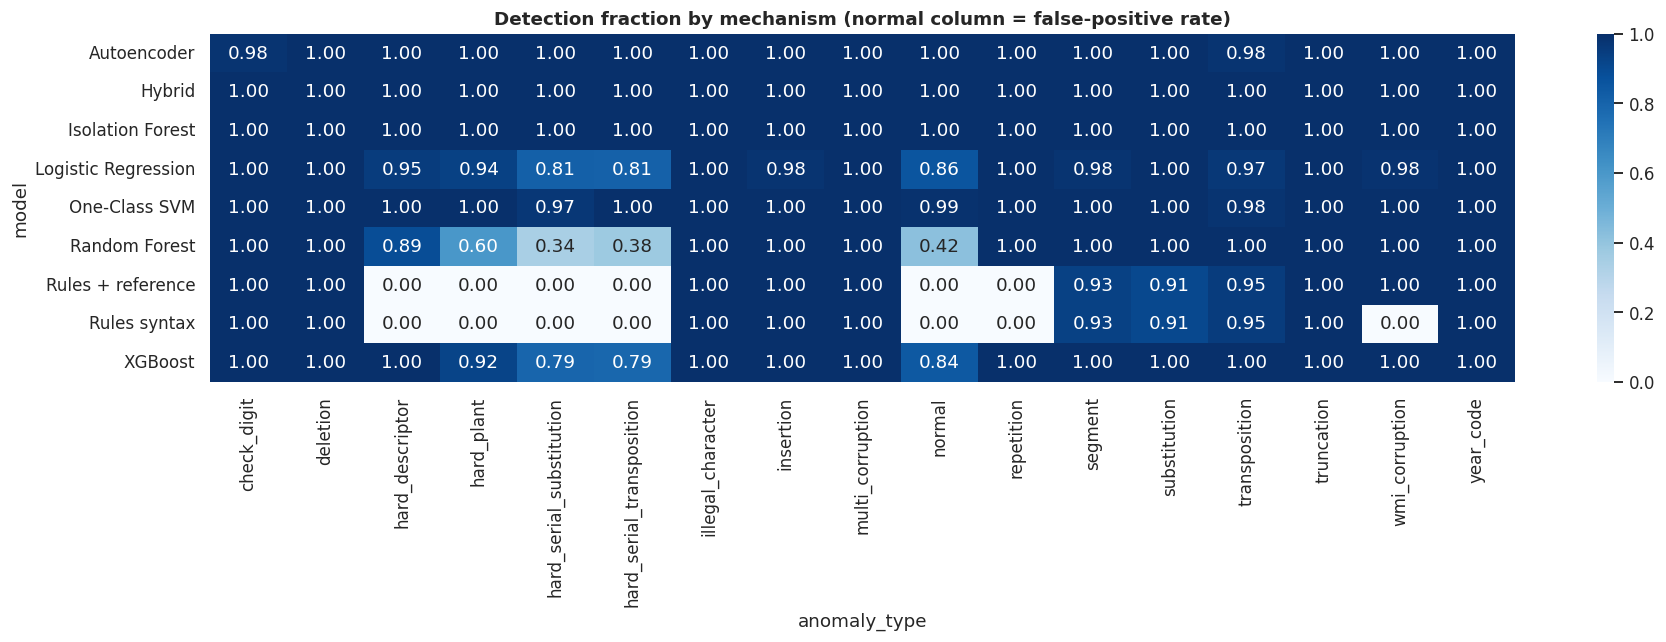

,subset,model,n,precision,recall,f1,pr_auc,false_positive_rate
0,easy,Logistic Regression,994,0.672,0.995,0.802,0.959,0.856
1,easy,Random Forest,994,0.808,1.000,0.894,1.000,0.419
2,easy,XGBoost,994,0.677,1.000,0.807,1.000,0.842
3,easy,Isolation Forest,994,0.638,1.000,0.779,0.702,1.000
4,easy,One-Class SVM,994,0.639,0.998,0.780,0.803,0.992
5,easy,Autoencoder,994,0.638,0.997,0.778,0.782,0.997
6,easy,Rules syntax,994,1.000,0.897,0.946,0.963,0.000
7,easy,Rules + reference,994,1.000,1.000,1.000,1.000,0.000
8,easy,Hybrid,994,0.638,1.000,0.779,0.677,1.000
9,hard,Logistic Regression,806,0.564,0.895,0.692,0.687,0.856


For the selected classifier, **hard_serial_transposition** is the lowest-recall type (78.8%) and **year_code** is the highest (100.0%); ties are not evidence of a meaningful ranking. The serial controls are especially important: they need not carry detectable anomaly signal. Strong hard-descriptor detection primarily demonstrates learning the simulated template distribution.

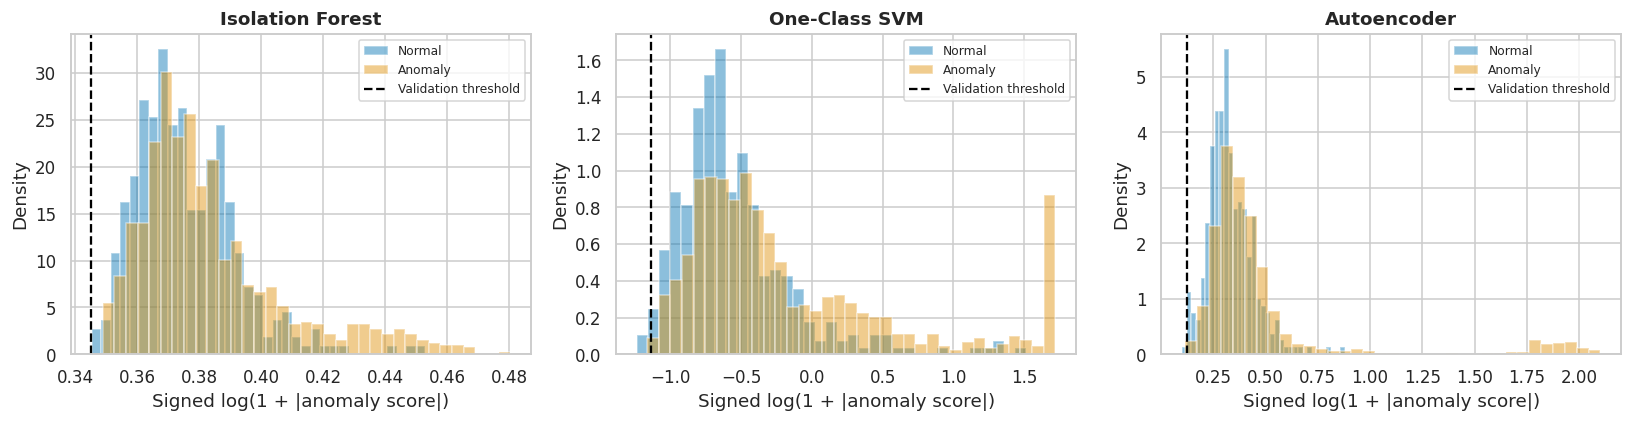

Score overlap explains unavoidable threshold tradeoffs. The dashed lines were fixed on validation. The signed-log display compresses extreme malformed-input scores without changing ordering. The autoencoder panel reports reconstruction error, not a calibrated probability.

In [19]:
type_rows=[]
for name,prediction in test_predictions.items():
    for kind,indices in test.groupby("anomaly_type").groups.items():
        type_rows.append(dict(model=name,anomaly_type=kind,n=len(indices),
                              detection_rate=float(prediction[np.asarray(indices)].mean())))
type_metrics=pd.DataFrame(type_rows)
type_heatmap=type_metrics.pivot(index="model",columns="anomaly_type",values="detection_rate")
plt.figure(figsize=(17,6))
sns.heatmap(type_heatmap,annot=True,fmt=".2f",vmin=0,vmax=1,cmap="Blues")
plt.title("Detection fraction by mechanism (normal column = false-positive rate)")
finish_plot("per_anomaly_detection")
type_metrics.to_csv(OUT / "anomaly_type_metrics.csv",index=False)
subset_rows=[]
subsets={"easy":test.difficulty.eq("easy"),"hard":test.difficulty.eq("hard"),
         "hard_serial_controls":test.anomaly_type.isin(["hard_serial_substitution","hard_serial_transposition"])}
for subset,anomaly_mask in subsets.items():
    mask=(test.label.eq(0)|anomaly_mask).to_numpy()
    for name,score in test_scores.items():
        subset_rows.append(dict(subset=subset,model=name,prevalence=float(test.label[mask].mean()),
            **metrics(test.label[mask],score[mask],thresholds[name])))
subset_metrics=pd.DataFrame(subset_rows)
display(subset_metrics[["subset","model","n","precision","recall","f1","pr_auc","false_positive_rate"]].round(3))
subset_metrics.to_csv(OUT / "easy_hard_metrics.csv",index=False)
selected_types=type_heatmap.loc[best_supervised].drop("normal").sort_values()
display(Markdown(f"For the selected classifier, **{selected_types.index[0]}** is the lowest-recall type "
    f"({selected_types.iloc[0]:.1%}) and **{selected_types.index[-1]}** is the highest "
    f"({selected_types.iloc[-1]:.1%}); ties are not evidence of a meaningful ranking. "
    "The serial controls are especially important: they need not carry detectable anomaly signal. "
    "Strong hard-descriptor detection primarily demonstrates learning the simulated template distribution."))
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,name in zip(axes,DETECTORS):
    scores=test_scores[name]
    # Signed log transform preserves score ordering and accommodates negative SVM scores.
    transformed=np.sign(scores)*np.log1p(np.abs(scores))
    for label in [0,1]:
        ax.hist(transformed[test.label.eq(label)],bins=35,density=True,alpha=.45,
                label="Normal" if label==0 else "Anomaly")
    t=detector_thresholds[name]
    ax.axvline(np.sign(t)*np.log1p(abs(t)),color="black",ls="--",label="Validation threshold")
    ax.set(title=name,xlabel="Signed log(1 + |anomaly score|)",ylabel="Density"); ax.legend(fontsize=8)
finish_plot("test_anomaly_score_distributions")
display(Markdown("Score overlap explains unavoidable threshold tradeoffs. The dashed lines were fixed on "
    "validation. The signed-log display compresses extreme malformed-input scores without changing "
    "ordering. The autoencoder panel reports reconstruction error, not a calibrated probability."))


## 28. Hold-one-anomaly-type-out generalization

The fixed Logistic Regression model for each holdout never sees that named mechanism in
training, preprocessing fitting or threshold validation. The normal-only detectors are
reused because no anomaly labels enter their fitting/early stopping. Their thresholds are
**recomputed before the test lock on known types only**, preventing the common leakage of
unseen-mechanism information into the decision policy. Calibration is not used in this experiment.

Related transformations can still share primitives; this is a category holdout, not a claim
of complete semantic novelty. The table pairs recall with normal FPR on the identical test
normal cohort. Counts matter because the smallest holdout estimates are noisy.


In [20]:
novel_rows=[]; novel_details=[]
for held_type in NOVEL_TYPES:
    mask=(test.anomaly_type.eq(held_type)|test.label.eq(0)).to_numpy()
    cohort=test.loc[mask]
    score_map={"Supervised":novel_models[held_type].predict_proba(cohort.vin.to_numpy())[:,1]}
    score_map.update({name:test_scores[name][mask] for name in DETECTORS})
    row={"Held-out anomaly":held_type,"n_anomalies":int(cohort.label.sum())}
    for name,score in score_map.items():
        threshold=novel_thresholds[held_type] if name=="Supervised" else novel_detector_thresholds[held_type][name]
        report=metrics(cohort.label,score,threshold)
        row[name+" recall"]=report["recall"]
        row[name+" FPR"]=report["false_positive_rate"]
        novel_details.append(dict(held_type=held_type,model=name,**report))
    novel_rows.append(row)
novel_results=pd.DataFrame(novel_rows)
display(novel_results.round(3))
novel_results.to_csv(OUT / "novel_anomaly_results.csv",index=False)
pd.DataFrame(novel_details).to_csv(OUT / "novel_anomaly_metrics.csv",index=False)
for row in novel_rows:
    recalls={name:row[name+" recall"] for name in ["Supervised"]+DETECTORS}
    winner=max(recalls,key=recalls.get)
    display(Markdown(f"For **{row['Held-out anomaly']}**, the highest observed recall is "
        f"**{winner} ({recalls[winner]:.1%})**, with normal FPR **{row[winner+' FPR']:.1%}**. "
        "Recall alone does not establish a preferred detector when false-positive rates differ; "
        "this finding is limited to the specified synthetic mechanism."))


,Held-out anomaly,n_anomalies,Supervised recall,Supervised FPR,Isolation Forest recall,Isolation Forest FPR,One-Class SVM recall,One-Class SVM FPR,Autoencoder recall,Autoencoder FPR
0,hard_descriptor,80,1.000,0.989,1.0,1.0,1.0,0.992,1.0,0.997
1,repetition,75,0.787,0.981,1.0,1.0,1.0,0.992,1.0,0.997


For **hard_descriptor**, the highest observed recall is **Supervised (100.0%)**, with normal FPR **98.9%**. Recall alone does not establish a preferred detector when false-positive rates differ; this finding is limited to the specified synthetic mechanism.

For **repetition**, the highest observed recall is **Isolation Forest (100.0%)**, with normal FPR **100.0%**. Recall alone does not establish a preferred detector when false-positive rates differ; this finding is limited to the specified synthetic mechanism.

## 29. Severity, ablation and manufacturer shift

Edit distance is the count in an optimal alignment, not necessarily the generator's operation
history (an adjacent swap may cost two). Checksum repair counts as an edit. One- and two-edit
rule-passing cases are reported separately. Corruption type and severity are confounded, so
a rising detection curve is not a causal effect of edit distance alone.

The ablation table uses the previously fitted models. WMI-frequency bins use training normal
counts only. An additional, fixed descriptor/plant stress set uses **test source groups only**,
fresh random descriptor strings and shifted plant symbols. Its labels are normal under the
same structural rule subset. Its rejection rate illustrates sensitivity to our simulated
normal-distribution assumption; it is not an estimate for a real manufacturer shift.


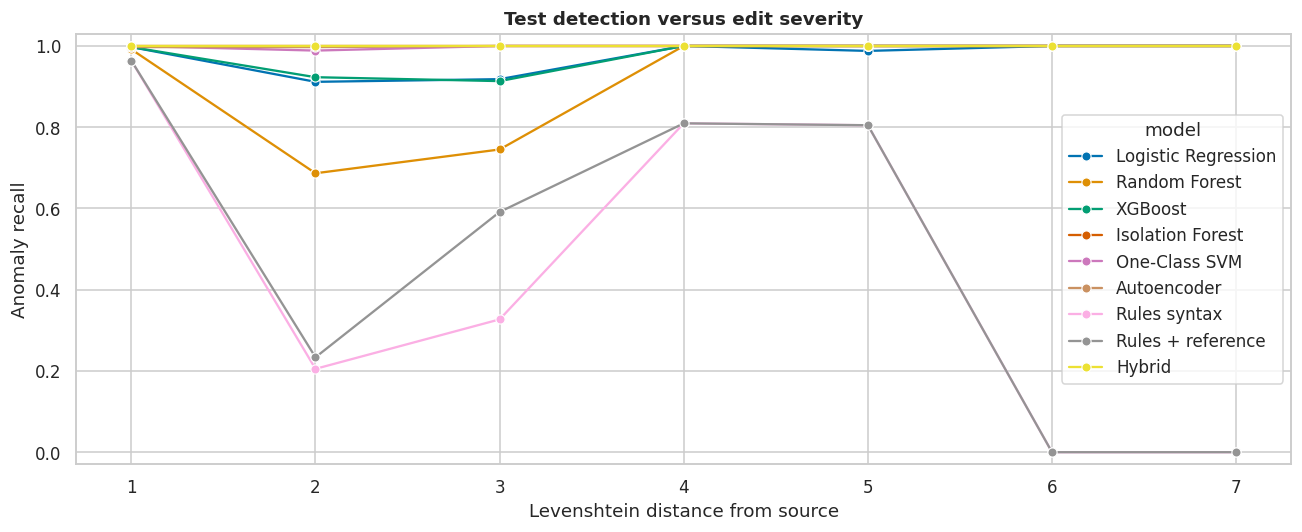

,Recall on 282 rule-passing one/two-edit anomalies
Logistic Regression,0.893617
Random Forest,0.599291
XGBoost,0.900709
Isolation Forest,1.000000
One-Class SVM,0.989362
Autoencoder,1.000000
Rules syntax,0.000000
Rules + reference,0.000000
Hybrid,1.000000


,features,subset,f1,recall,pr_auc,false_positive_rate
0,basic,all,0.856,0.998,0.862,1.000
1,basic,easy,0.777,0.997,0.821,1.000
2,basic,hard,0.712,1.000,0.689,1.000
3,ngrams,all,0.857,0.998,0.884,0.997
4,ngrams,easy,0.778,0.997,0.861,0.997
5,ngrams,hard,0.713,1.000,0.694,0.997
6,domain,all,0.856,0.994,0.934,0.989
7,domain,easy,0.781,1.000,1.000,0.989
8,domain,hard,0.709,0.987,0.562,0.989
9,combined,all,0.858,1.000,0.943,0.994


Compare the hard rows of the ablation table first. Domain-only performance measures how far explicit rules and reference information go; basic/n-gram performance measures additional statistical signal. A combined-model gain can reflect simulated grammar assumptions. The severity curve should be read with type counts, not as evidence of real-world fraud severity.

,model,wmi_bin,n,false_positive_rate
0,Logistic Regression,Common,251,0.844622
1,Logistic Regression,Rare (<2.5% train normals),109,0.880734
2,Random Forest,Common,251,0.354582
3,Random Forest,Rare (<2.5% train normals),109,0.568807
4,XGBoost,Common,251,0.808765
5,XGBoost,Rare (<2.5% train normals),109,0.917431
6,Isolation Forest,Common,251,1.000000
7,Isolation Forest,Rare (<2.5% train normals),109,1.000000
8,One-Class SVM,Common,251,0.988048
9,One-Class SVM,Rare (<2.5% train normals),109,1.000000


,Rejection rate on shifted rule-valid synthetic normals
Rules + reference,0.0
XGBoost,1.0
Autoencoder,1.0
Hybrid,1.0


In [21]:
severity_rows=[]
for name,prediction in test_predictions.items():
    for severity in sorted(test.loc[test.label.eq(1),"edit_distance"].unique()):
        mask=(test.label.eq(1)&test.edit_distance.eq(severity)).to_numpy()
        severity_rows.append(dict(model=name,edits=int(severity),n=int(mask.sum()),
                                  recall=float(prediction[mask].mean())))
severity_metrics=pd.DataFrame(severity_rows)
plt.figure(figsize=(12,5))
sns.lineplot(data=severity_metrics,x="edits",y="recall",hue="model",marker="o")
plt.ylim(-.03,1.03); plt.title("Test detection versus edit severity")
plt.ylabel("Anomaly recall"); plt.xlabel("Levenshtein distance from source")
finish_plot("severity_performance")
severity_metrics.to_csv(OUT / "severity_metrics.csv",index=False)
subtle=(test.difficulty.eq("hard")&test.edit_distance.le(2)).to_numpy()
display(pd.Series({name:float(p[subtle].mean()) for name,p in test_predictions.items()},
                  name=f"Recall on {int(subtle.sum())} rule-passing one/two-edit anomalies"))
ablation_rows=[]
for mode,pipe in ablations.items():
    scores=pipe.predict_proba(test.vin.to_numpy())[:,1]
    for subset in ("all","easy","hard"):
        mask=np.ones(len(test),dtype=bool) if subset=="all" else (test.label.eq(0)|test.difficulty.eq(subset)).to_numpy()
        ablation_rows.append(dict(features=mode,subset=subset,
            **metrics(test.label[mask],scores[mask],ablation_thresholds[mode])))
ablation_metrics=pd.DataFrame(ablation_rows)
display(ablation_metrics[["features","subset","f1","recall","pr_auc","false_positive_rate"]].round(3))
ablation_metrics.to_csv(OUT / "ablation_metrics.csv",index=False)
display(Markdown("Compare the hard rows of the ablation table first. Domain-only performance measures "
    "how far explicit rules and reference information go; basic/n-gram performance measures "
    "additional statistical signal. A combined-model gain can reflect simulated grammar assumptions. "
    "The severity curve should be read with type counts, not as evidence of real-world fraud severity."))

normal_mask=test.label.eq(0).to_numpy()
normal_frequency=np.array([compact.frequencies.get(v[:3],0) for v in test.loc[normal_mask,"vin"]])
rarity=np.where(normal_frequency<.025,"Rare (<2.5% train normals)","Common")
rarity_rows=[]
for name,pred in test_predictions.items():
    for label in sorted(set(rarity)):
        mask=rarity==label
        rarity_rows.append(dict(model=name,wmi_bin=label,n=int(mask.sum()),
                               false_positive_rate=float(pred[normal_mask][mask].mean())))
display(pd.DataFrame(rarity_rows))
pd.DataFrame(rarity_rows).to_csv(OUT / "wmi_rarity_metrics.csv",index=False)

shift_rng=np.random.default_rng(RANDOM_STATE+500)
shift_vins=[]
for vin in test.loc[normal_mask,"vin"]:
    c=list(vin)
    c[3:8]=[draw(LETTERS if i==3 else ALPHABET,shift_rng) for i in range(5)]
    c[10]=draw(LETTERS,shift_rng)
    shifted=repair_checksum("".join(c)); assert rules_score(shifted)==0
    shift_vins.append(shifted)
shift_results={"Rules + reference":0.0,
    best_supervised:float((supervised_scores(best_supervised,shift_vins)>=sup_thresholds[best_supervised]).mean()),
    best_detector:float((detector_scores(best_detector,shift_vins)>=detector_thresholds[best_detector]).mean()),
    "Hybrid":float((hybrid_scores(shift_vins)>=.5).mean())}
display(pd.Series(shift_results,name="Rejection rate on shifted rule-valid synthetic normals"))
save_json(shift_results,"normal_distribution_shift.json")


## 30. Explainability

Random Forest and XGBoost native importances rank splitting usefulness; they are biased
toward features with more possible splits and are not causal explanations. Logistic
coefficients describe standardized feature associations with the raw model log odds.
For one candidate, coefficient × transformed feature gives an exact additive contribution
to the *uncalibrated logistic* score. This does not explain a tree, a calibrated probability
or physical vehicle status. SHAP is omitted to keep runtime and dependencies bounded.


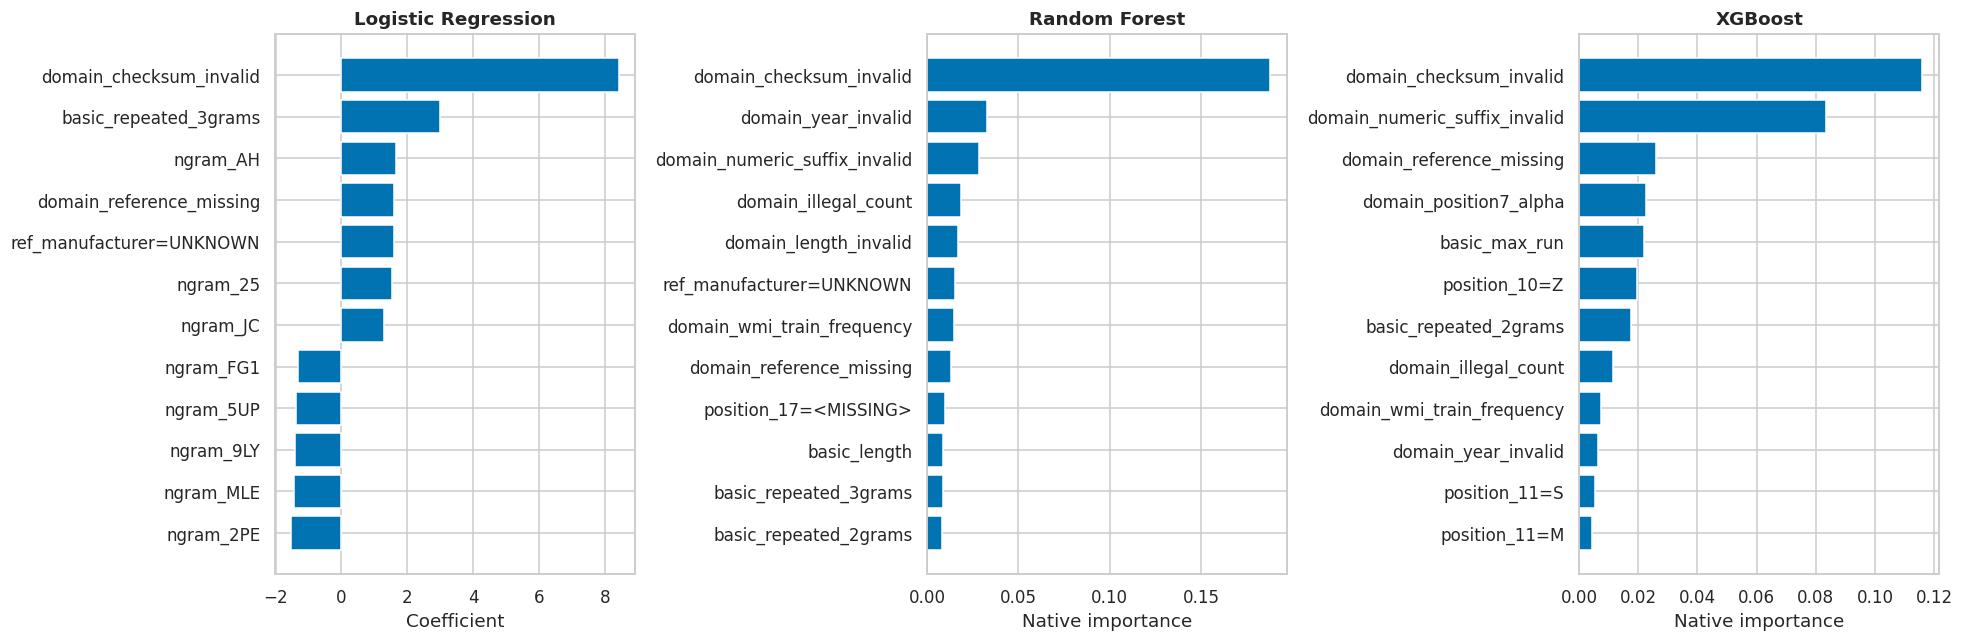

,feature,log_odds_contribution
3153,ngram_ZLW,-10.995852
2985,ngram_VB2,-5.558131
1065,ngram_2ZL,-5.530017
2020,ngram_B2Z,-5.036730
1064,ngram_2Z,-3.925229
331,position_08=W,-3.840838
167,position_04=B,3.816571
3,basic_entropy,3.829846
2119,ngram_DK,4.562002
45,domain_checksum_invalid,17.144959


The plots reveal whether the fitted model relies mostly on rule failures, repetition, position categories or n-grams. The local table is an exact raw-logistic decomposition relative to its intercept; correlated predictors may distribute signal across several terms. It is an association-based explanation, not evidence about a vehicle.

In [22]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
importance_tables=[]
for ax,name in zip(axes,["Logistic Regression","Random Forest","XGBoost"]):
    pipe=supervised[name]; names=pipe.named_steps["features"].get_feature_names_out()
    model=pipe.named_steps["model"]
    values=model.coef_[0] if name=="Logistic Regression" else model.feature_importances_
    table=pd.DataFrame({"feature":names,"importance":values})
    importance_tables.append(table.assign(model=name))
    chosen=table.iloc[np.argsort(np.abs(values))[-12:]].sort_values("importance")
    ax.barh(chosen.feature,chosen.importance); ax.set_title(name)
    ax.set_xlabel("Coefficient" if name=="Logistic Regression" else "Native importance")
finish_plot("feature_importance")
pd.concat(importance_tables).to_csv(OUT / "feature_importance.csv",index=False)
lr=supervised["Logistic Regression"]
example_index=int(np.argmax(test_scores["Logistic Regression"]))
example_vin=test.vin.iloc[example_index]
vector=lr[:-1].transform([example_vin])
contribution=vector.toarray()[0]*lr.named_steps["model"].coef_[0]
assert np.isclose(contribution.sum()+lr.named_steps["model"].intercept_[0],lr.decision_function([example_vin])[0])
local_explanation=pd.DataFrame({"feature":lr.named_steps["features"].get_feature_names_out(),
                                 "log_odds_contribution":contribution})
display(local_explanation.iloc[np.argsort(np.abs(contribution))[-10:]].sort_values("log_odds_contribution"))
display(Markdown("The plots reveal whether the fitted model relies mostly on rule failures, repetition, "
    "position categories or n-grams. The local table is an exact raw-logistic decomposition "
    "relative to its intercept; correlated predictors may distribute signal across several terms. "
    "It is an association-based explanation, not evidence about a vehicle."))


## 31. Explicit false-positive and false-negative analysis

The following limited masked examples show WMI training rarity, entropy, edit distance,
rule violations and checksum status. These are diagnostic associations, not invented reasons.
When no errors exist in a category, the notebook reports zero rather than fabricating examples.
False negatives with valid checksums may be subtle or distribution-preserving. Rare-WMI
false positives suggest coverage/sampling issues but cannot establish causality.


In [23]:
error_frame=test[["vin","group_id","label","anomaly_type","edit_distance","difficulty"]].copy()
error_frame["prediction"]=test_predictions[best_supervised]
error_frame["probability"]=test_scores[best_supervised]
error_frame["entropy"]=test.vin.map(lambda v:basic_features(v)["entropy"])
error_frame["wmi_train_frequency"]=test.vin.map(lambda v:compact.frequencies.get(v[:3],0))
error_frame["checksum"]=test.vin.map(lambda v:VINValidator.validate(v)["check_digit"])
error_frame["violations"]=test.vin.map(lambda v:"; ".join(VINValidator.validate(v)["violations"]) or "none")
error_frame["vin"]=error_frame.vin.map(lambda v:v[:11]+"*"*max(0,len(v)-11))
for label,mask in [("False positives",error_frame.label.eq(0)&error_frame.prediction.eq(1)),
                   ("False negatives",error_frame.label.eq(1)&error_frame.prediction.eq(0))]:
    errors=error_frame[mask]
    display(Markdown(f"**{label}: {len(errors)}**"))
    if len(errors):
        display(errors.drop(columns="group_id").head(6))
        display(errors.groupby("anomaly_type").agg(n=("vin","size"),mean_entropy=("entropy","mean"),
            mean_wmi_frequency=("wmi_train_frequency","mean"),median_edits=("edit_distance","median")))
error_frame[error_frame.label.ne(error_frame.prediction)].drop(columns="group_id").to_csv(
    OUT / "masked_error_analysis.csv",index=False)


**False positives: 303**

,vin,label,anomaly_type,edit_distance,difficulty,prediction,probability,entropy,wmi_train_frequency,checksum,violations
0,19VB2ZLW3DK******,0,normal,0,normal,1,0.440134,3.734522,0.100000,PASS,none
8,19UHZRUP5KK******,0,normal,0,normal,1,0.585223,3.454822,0.154167,PASS,none
12,1FL32STN6AB******,0,normal,0,normal,1,0.437494,3.572469,0.043452,PASS,none
16,5KCSL8VC1RT******,0,normal,0,normal,1,0.601936,3.454822,0.019643,PASS,none
20,1HGER8B30FN******,0,normal,0,normal,1,0.428954,3.734522,0.041071,PASS,none
24,2HH9YXM02JT******,0,normal,0,normal,1,0.419840,3.616875,0.020238,PASS,none


,n,mean_entropy,mean_wmi_frequency,median_edits
anomaly_type,,,,
normal,303,3.553351,0.051222,0.0


**False negatives: 46**

,vin,label,anomaly_type,edit_distance,difficulty,prediction,probability,entropy,wmi_train_frequency,checksum,violations
7,1F7VJ2UJ3JP******,1,hard_serial_substitution,2,hard,0,0.321217,3.101881,0.047619,PASS,none
27,2HH9YXM0XJU******,1,hard_plant,2,hard,0,0.378262,3.616875,0.020238,PASS,none
35,1FA2JTGKXSK******,1,hard_serial_substitution,2,hard,0,0.329902,3.381580,0.049405,PASS,none
39,1LNZKEHL0HM******,1,hard_serial_substitution,2,hard,0,0.361940,3.499228,0.034524,PASS,none
91,19XWC2LT8LD******,1,hard_plant,2,hard,0,0.335395,3.454822,0.068452,PASS,none
139,1FA9DZW13PZ******,1,hard_serial_substitution,2,hard,0,0.294954,3.572469,0.049405,PASS,none


,n,mean_entropy,mean_wmi_frequency,median_edits
anomaly_type,,,,
hard_plant,7,3.551543,0.042347,2.0
hard_serial_substitution,21,3.546682,0.055584,2.0
hard_serial_transposition,18,3.593481,0.055159,3.0


## 32. Rules versus ML versus hybrid: measured added value

The hybrid is the predeclared OR detector (moderate or high counts positive). It can improve
recall while adding false alarms. Incremental true positives relative to rules and additional
false positives are counted explicitly. “ML-only” still has rule features in its learned
pipeline; interpret it together with the feature ablation. No method is declared universally
superior from aggregate benchmark performance.


In [24]:
display(comparison.loc[["Rules syntax","Rules + reference",best_supervised,best_detector,"Hybrid"]])
rule_prediction=test_predictions["Rules + reference"]
hybrid_prediction=test_predictions["Hybrid"]
added_tp=int(((hybrid_prediction==1)&(rule_prediction==0)&test.label.eq(1)).sum())
added_fp=int(((hybrid_prediction==1)&(rule_prediction==0)&test.label.eq(0)).sum())
display(Markdown(f"Compared with rules plus reference, the hybrid detects **{added_tp} additional "
    f"synthetic anomalies** and introduces **{added_fp} additional false positives** on the locked test. "
    "The hard subset and shifted-normal rejection rate determine whether that apparent gain is "
    "useful under these assumptions. A rule-passing transformed VIN may still be a valid identifier."))


,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,tn,fp,fn,tp,n
model,,,,,,,,,,,,,
Rules syntax,0.645139,1.000000,0.526852,0.690115,0.763426,0.881713,0.000000,0.473148,360,0,511,569,1440
Rules + reference,0.690278,1.000000,0.587037,0.739790,0.793519,0.896759,0.000000,0.412963,360,0,446,634,1440
XGBoost,0.757639,0.773373,0.957407,0.855606,0.854122,0.955192,0.841667,0.042593,57,303,46,1034,1440
Autoencoder,0.749306,0.750174,0.998148,0.856575,0.646956,0.849760,0.997222,0.001852,1,359,2,1078,1440
Hybrid,0.750000,0.750000,1.000000,0.857143,0.559259,0.772932,1.000000,0.000000,0,360,0,1080,1440


Compared with rules plus reference, the hybrid detects **446 additional synthetic anomalies** and introduces **360 additional false positives** on the locked test. The hard subset and shifted-normal rejection rate determine whether that apparent gain is useful under these assumptions. A rule-passing transformed VIN may still be a valid identifier.

## 33. SerialGuard hybrid engine and model artifacts

The engine returns structural checks, scope/coverage warnings, supervised benchmark probability,
all three anomaly scores, validation thresholds and the selected detector. A rule failure gives
high structural anomaly; an unknown WMI or unsupported scope gives at least moderate. Both
learned flags give high; one gives moderate; none gives low. Out-of-scope analysis is labeled
provisional. The deployment categories distinguish coverage uncertainty from hard invalidity;
both moderate and high retain the evaluated hybrid's positive decision.

Artifacts include preprocessing, every family winner, calibrators, thresholds, autoencoder
weights, input dimension and reference/experiment metadata. Python objects defined in a
notebook should be loaded in a trusted environment **after rerunning their class definitions**.
Joblib files are executable pickle-based objects; load only artifacts you trust. This is a
reusable inference prototype, not a monitored or audited production fraud service.


In [25]:
DISCLAIMER = ("SerialGuard evaluates VIN structure and statistical patterns. It does not determine "
    "whether a vehicle is stolen, cloned, counterfeit, legally registered, or otherwise fraudulent.")

class SerialGuardEngine:
    """Analyze one candidate using the already fitted and validation-locked system."""
    def analyze(self, value, us_checksum=True):
        if not isinstance(value,str) or len(value)>128:
            raise ValueError("Enter a VIN as text (maximum 128 input characters).")
        vin=normalize_vin(value)
        if not vin: raise ValueError("Enter a nonempty VIN.")
        rule=VINValidator.validate(vin,us_checksum=us_checksum)
        probability=float(supervised_scores(best_supervised,[vin])[0])
        scores={name:float(detector_scores(name,[vin])[0]) for name in DETECTORS}
        supervised_flag=probability>=sup_thresholds[best_supervised]
        detector_flag=scores[best_detector]>=detector_thresholds[best_detector]
        coverage_warning=not rule["reference_present"] or rule["out_of_scope"]
        high=bool(rule["violations"]) or (supervised_flag and detector_flag)
        moderate=coverage_warning or supervised_flag or detector_flag
        category="HIGH STRUCTURAL ANOMALY" if high else "MODERATE STRUCTURAL ANOMALY" if moderate else "LOW STRUCTURAL ANOMALY"
        reasons=rule["violations"]+rule["warnings"]
        if supervised_flag: reasons.append("supervised benchmark probability exceeds validation threshold")
        if detector_flag: reasons.append(f"{best_detector} score exceeds validation threshold")
        if not reasons: reasons=["passes selected structural checks; learned scores below thresholds"]
        if not us_checksum:
            reasons.append("non-U.S. scope: learned models still use U.S. benchmark features; assessment provisional")
        return dict(input=rule,assessment=category,supervised_model=best_supervised,
            supervised_anomaly_probability=probability,supervised_threshold=sup_thresholds[best_supervised],
            selected_detector=best_detector,anomaly_scores=scores,anomaly_thresholds=detector_thresholds,
            explanation=reasons,disclaimer=DISCLAIMER,
            applicability="provisional/out of scope" if rule["out_of_scope"] or not us_checksum else "U.S. passenger-car rule subset")

engine=SerialGuardEngine()
smoke_inputs=["1HGCM82633A123456","1HGCM82633A004352","I"*17,"ABC",train.vin.iloc[0].lower()]
for candidate in smoke_inputs:
    output=engine.analyze(candidate)
    assert np.isfinite(output["supervised_anomaly_probability"])
    assert all(np.isfinite(s) for s in output["anomaly_scores"].values())
    assert output["assessment"] in ["LOW STRUCTURAL ANOMALY","MODERATE STRUCTURAL ANOMALY","HIGH STRUCTURAL ANOMALY"]
    json.dumps(output)
for candidate in ("",None,"A"*129):
    try: engine.analyze(candidate)
    except ValueError: pass
    else: raise AssertionError("Malformed input must fail clearly")
# Check deployed positive decisions match the evaluated policy on the test cohort.
engine_positive=np.array([engine.analyze(v)["assessment"]!="LOW STRUCTURAL ANOMALY" for v in test.vin.iloc[:20]])
assert np.array_equal(engine_positive,test_predictions["Hybrid"][:20].astype(bool))
bundle=dict(supervised=supervised,calibrators=calibrators,calibration_retained=use_calibration,
    compact=compact,isolation=isolation,oneclass=oneclass,lock=LOCK,reference=WMI_INFO,
    configuration=CONFIG,environment=VERSIONS)
joblib.dump(bundle,OUT / "models" / "serialguard_bundle.joblib",compress=3)
joblib.dump(supervised[best_supervised][:-1],OUT / "models" / "best_preprocessing.joblib",compress=3)
torch.save(dict(state_dict={k:v.cpu() for k,v in autoencoder.state_dict().items()},
    input_dim=Z_normal.shape[1],architecture=[Z_normal.shape[1],48,12,48,Z_normal.shape[1]]),
    OUT / "models" / "autoencoder.pt")
# Verify serialization parity without retraining or changing decisions.
reloaded=joblib.load(OUT / "models" / "serialguard_bundle.joblib")
assert np.allclose(reloaded["supervised"][best_supervised].predict_proba(smoke_inputs),
                   supervised[best_supervised].predict_proba(smoke_inputs))
checkpoint=torch.load(OUT / "models" / "autoencoder.pt",map_location="cpu",weights_only=True)
restored_ae=VINAutoencoder(checkpoint["input_dim"])
restored_ae.load_state_dict(checkpoint["state_dict"]); restored_ae.eval()
with torch.no_grad():
    sample=torch.from_numpy(Z_normal[:5])
    assert np.allclose(restored_ae(sample).numpy(),autoencoder(sample.to(DEVICE)).cpu().numpy(),atol=1e-5)
print("Inference, feature consistency, serialization and deployed-policy sanity tests passed.")


Inference, feature consistency, serialization and deployed-policy sanity tests passed.


## 34. Gradio analysis interface

The demo accepts one identifier and analyzes it with the fitted artifacts. It never generates
replacement VINs. The default scope is a U.S.-market passenger car; selecting otherwise
explicitly makes learned assessments provisional. No input VINs are written to a user log.
In Colab the final launch cell requests a temporary public Gradio link (no API key required).
Anyone with the link can access it while the runtime is alive. Avoid entering sensitive identifiers.
If the tunnel service is unavailable, local launch is attempted and all computed artifacts
remain available. The complete results summary is written before starting the server.


In [26]:
def gradio_predict(vin, us_market=True):
    """UI adapter with bounded input and structured errors."""
    try:
        result=engine.analyze(vin,us_checksum=us_market)
    except ValueError as exc:
        return "### Input error",str(exc),{},{}
    r=result["input"]
    status=lambda ok:"PASS" if ok else "FAIL"
    summary=(f"### {result['assessment']}\n"
        f"**Normalized VIN:** `{r['normalized_vin']}` · **Length:** {r['length']}\n\n"
        f"WMI: `{r['wmi']}` · Year code: `{r['year_code']}` · Plant: `{r['plant_code']}`\n\n"
        f"**Applicability:** {result['applicability']}")
    checks={"Length":status(r["length_ok"]),"Allowed characters":status(r["characters_ok"]),
        "Check digit":r["check_digit"],"WMI reference":"PRESENT" if r["reference_present"] else "UNKNOWN / LIMITED COVERAGE",
        "Reference details":r["reference"],"Rule violations":r["violations"],"Coverage warnings":r["warnings"]}
    analysis={"Supervised model":best_supervised,"Benchmark anomaly probability":result["supervised_anomaly_probability"],
        "Supervised threshold":result["supervised_threshold"],"Selected detector":best_detector,
        "Scores (higher = more anomalous)":result["anomaly_scores"],"Validation thresholds":result["anomaly_thresholds"]}
    reasons="\n".join("- "+reason for reason in result["explanation"])
    return summary,reasons,checks,analysis

with gr.Blocks(title="SerialGuard | VIN structural analysis",theme=gr.themes.Soft()) as demo:
    gr.Markdown("# SerialGuard\nVIN structure and statistical anomaly analysis")
    gr.Markdown("**"+DISCLAIMER+"**")
    gr.Markdown("Research benchmark trained on generated VINs with simulated descriptor/plant patterns. "
                "Scores are not real-world authenticity probabilities.")
    gr.Markdown(f"**Operating-point context:** the hybrid flagged "
        f"{operating_validation['Hybrid']['false_positive_rate']:.1%} of generated normal validation examples. "
        "A high false-alarm rate makes this unsuitable for operational screening without further validation.")
    with gr.Row():
        vin_input=gr.Textbox(label="VIN",placeholder="1HGCM82633A123456",max_lines=1)
        us_input=gr.Checkbox(value=True,label="Apply U.S. passenger-car checksum scope")
    analyze_button=gr.Button("Analyze VIN",variant="primary")
    assessment_output=gr.Markdown()
    explanation_output=gr.Markdown()
    with gr.Row():
        rule_output=gr.JSON(label="Deterministic validation")
        ml_output=gr.JSON(label="ML scores and locked thresholds")
    analyze_button.click(gradio_predict,[vin_input,us_input],
        [assessment_output,explanation_output,rule_output,ml_output],api_name=False)
    gr.Examples(examples=[["1HGCM82633A123456",True],["1HGCM82633A004352",True]],inputs=[vin_input,us_input])
    gr.Markdown("WMI reference: NHTSA vPIC. Unknown WMI means limited coverage, not proven invalidity. "
                "This interface analyzes identifiers and does not create them.")
assert len(gradio_predict("1HGCM82633A123456"))==4
assert gradio_predict("")[0]=="### Input error"
print("Gradio interface constructed; inference adapter passed sanity checks.")


Gradio interface constructed; inference adapter passed sanity checks.


## 35. Limitations · 36. Ethics and responsible use

- There are zero observed vehicle VINs and zero observed fraud labels in this experiment.
  Synthetic corruption is not observed fraud, and structural validity cannot establish legal identity.
- WMI reference coverage is limited and mutable. Rarity is generated sampling frequency, not
  real-world rarity. Missing WMI/country data cannot be treated as a definitive negative.
- Manufacturer-specific semantics vary. Simulated descriptor and plant templates are not verified
  manufacturer assignments. Good detection may mean learning generator artifacts.
- Illegal-character and length anomalies are intentionally easy. Aggregate scores may be
  artificially high; hard subsets, serial controls, ablations and shift tests are essential.
- Uniform serial edits may produce another equally plausible identifier. There may be no
  observable signal in VIN text alone. A negative result is scientifically appropriate.
- This is a single seeded group split with limited validation and few manufacturer families.
  Bootstrap intervals quantify test-family sampling variability, not synthetic-to-real validity.
- Novel-category holdouts still share primitives with seen mechanisms. They do not demonstrate
  resistance to an adaptive adversary. Thresholds trade off false alarms and missed anomalies.
- Dataset retrieval and public Gradio tunnels depend on service availability. The reference
  snapshot is a fallback, not current authoritative coverage. Package/runtime drift is recorded.
- Generated strings are benchmark material, not assigned VINs or replacement identifiers.
  The demo provides analysis only. Real deployment needs lawful observed data, independent
  validation, privacy controls, monitoring, rate limits and human review processes.

The notebook does not accuse people or identify vehicle ownership. Structural flags should
lead to appropriate verification, never a claim that a vehicle is stolen or fraudulent.


## 37. Computed results and artifact manifest

The summary below is assembled from the locked predictions. It reports the validation-selected
families rather than choosing a new winner after viewing the test. The ZIP contains tables,
figures, configuration, source provenance and fitted artifacts; full synthetic VIN lists stay
in the runtime cache. No metric is filled in before execution.


In [27]:
summary=dict(dataset_rows=len(data),unique_source_groups=int(data.group_id.nunique()),
    generated_anomalies=int(data.label.sum()),observed_vins=0,source_modes=[p["mode"] for p in provenance],
    best_supervised=best_supervised,best_unsupervised=best_detector,
    selected_supervised_test_metrics=comparison.loc[best_supervised].to_dict(),
    always_anomalous_baseline=always_anomalous,
    rules_baseline=comparison.loc["Rules + reference"].to_dict(),hybrid=comparison.loc["Hybrid"].to_dict(),
    hardest_anomaly_type=selected_types.index[0],easiest_anomaly_type=selected_types.index[-1],
    novel_anomaly_findings=novel_results.to_dict("records"),additional_hybrid_true_positives=added_tp,
    additional_hybrid_false_positives=added_fp,shifted_normal_rejection=shift_results,
    group_bootstrap_f1_intervals=intervals,
    limitations=["No observed vehicle or fraud labels","Simulated VDS/plant distributions",
        "Limited WMI coverage","Serial controls may be statistically indistinguishable",
        "Synthetic prevalence/calibration; not physical or legal authenticity"])
save_json(summary,"experiment_summary.json")
final_metrics=comparison.loc[best_supervised]
summary_markdown=f"""### SerialGuard: results from this run

- **Dataset:** {len(data):,} rows; {data.group_id.nunique():,} source groups; {int(data.label.sum()):,} generated anomalies; **0 observed vehicle VINs**.
- **Selected on validation:** {best_supervised}; normal-only detector: {best_detector}.
- **Selected classifier, locked test:** F1 {final_metrics.f1:.3f}, precision {final_metrics.precision:.3f}, recall {final_metrics.recall:.3f}, ROC-AUC {final_metrics.roc_auc:.3f}, PR-AUC/AP {final_metrics.pr_auc:.3f}.
- **Rules + reference F1:** {comparison.loc['Rules + reference','f1']:.3f}; **hybrid F1:** {comparison.loc['Hybrid','f1']:.3f}.
- **Normal false-positive rates:** classifier {final_metrics.false_positive_rate:.1%}; hybrid {comparison.loc['Hybrid','false_positive_rate']:.1%}.
- **No-learning reference:** flagging everything gives F1 {always_anomalous['f1']:.3f} with 100% false positives. High F1 alone is insufficient for deployment.
- **Incremental hybrid detections:** {added_tp} additional true positives and {added_fp} additional false positives.
- **Lowest / highest selected-model type recall:** {selected_types.index[0]} / {selected_types.index[-1]} (ties possible).
- **Interpretation:** performance concerns this synthetic benchmark only. Passing checks or receiving a low score does not establish vehicle authenticity.
"""
display(Markdown(summary_markdown))
display(novel_results.round(3))
(OUT / "experiment_summary.md").write_text(summary_markdown,encoding="utf-8")
save_json({"validation":calibration_validation,"test":calibration_test},"calibration_summary.json")
save_json({"validator_vectors":"passed","no_group_overlap":True,"no_exact_vin_overlap":True,
    "feature_dimensions":"passed","inference":"passed","serialization":"passed",
    "gradio_adapter":"passed","test_lock":LOCK["locked_utc"]},"sanity_tests.json")
manifest={str(p.relative_to(OUT)):hashlib.sha256(p.read_bytes()).hexdigest()
          for p in OUT.rglob("*") if p.is_file() and p.name!="artifact_manifest.json"}
save_json(manifest,"artifact_manifest.json")
import shutil
archive=shutil.make_archive(str(ROOT / "serialguard_results"),"zip",root_dir=OUT)
print("Artifacts:",OUT.resolve())
print("Downloadable results archive:",archive)
print("Use Colab's Files sidebar to download serialguard/serialguard_results.zip.")


### SerialGuard: results from this run

- **Dataset:** 9,600 rows; 2,400 source groups; 7,200 generated anomalies; **0 observed vehicle VINs**.
- **Selected on validation:** XGBoost; normal-only detector: Autoencoder.
- **Selected classifier, locked test:** F1 0.856, precision 0.773, recall 0.957, ROC-AUC 0.854, PR-AUC/AP 0.955.
- **Rules + reference F1:** 0.740; **hybrid F1:** 0.857.
- **Normal false-positive rates:** classifier 84.2%; hybrid 100.0%.
- **No-learning reference:** flagging everything gives F1 0.857 with 100% false positives. High F1 alone is insufficient for deployment.
- **Incremental hybrid detections:** 446 additional true positives and 360 additional false positives.
- **Lowest / highest selected-model type recall:** hard_serial_transposition / year_code (ties possible).
- **Interpretation:** performance concerns this synthetic benchmark only. Passing checks or receiving a low score does not establish vehicle authenticity.


,Held-out anomaly,n_anomalies,Supervised recall,Supervised FPR,Isolation Forest recall,Isolation Forest FPR,One-Class SVM recall,One-Class SVM FPR,Autoencoder recall,Autoencoder FPR
0,hard_descriptor,80,1.000,0.989,1.0,1.0,1.0,0.992,1.0,0.997
1,repetition,75,0.787,0.981,1.0,1.0,1.0,0.992,1.0,0.997


Artifacts: /content/serialguard/outputs
Downloadable results archive: /content/serialguard/serialguard_results.zip
Use Colab's Files sidebar to download serialguard/serialguard_results.zip.


## 38. Future work and launch

Next evidence should come from an authorized observed-VIN cohort with reliable structural
error annotations, manufacturer-submitted descriptor/plant tables, unseen manufacturer and
time-based splits, and a realistic prevalence study. Repeat group splits with confidence
intervals and select operating thresholds against explicit false-positive costs. Monitor
coverage and drift before treating this as an operational screening aid. Vehicle authenticity
would require independent documentary and physical evidence beyond VIN text.

The cell below launches the completed interface. A Colab session must remain running for
the demo link to work. All experiment results are saved even if the share service is down.


In [28]:
if LAUNCH_DEMO:
    in_colab="google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))
    try:
        demo.launch(share=in_colab,inline=True,prevent_thread_lock=True,show_error=True)
    except Exception as exc:
        logging.warning("Demo share/inline launch failed: %s. Results already saved at %s",exc,OUT)
        try:
            demo.close()
            demo.launch(share=False,inline=False,prevent_thread_lock=True,show_error=True)
        except Exception as local_exc:
            logging.warning("Local demo launch unavailable: %s. engine.analyze remains usable.",local_exc)
else:
    print("Demo launch disabled by configuration; engine and Gradio adapter are fitted and tested.")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9523a5b9d11ff306d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
